<a href="https://colab.research.google.com/github/AI-fanatic24/ASD-DS-AI-ML-Internship/blob/main/Google_Play_Store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET IS AS OF FEB 2019
Citation of dataset:  L. Gupta, "Google Play Store Apps," Feb 2019. [Online]. Available: https://www.kaggle.com/lava18/google-play-store-apps

OBJECTIVE:
•
Load and clean the dataset.
•
Handle missing values and duplicates.
•
Analyze ratings and their distribution.
•
Identify most popular app categories.
•
Explore correlation between installs, reviews, and ratings.
•
Check app pricing trends (free vs paid).
•
Visualize insights using bar plots, box plots, pie charts, etc.
Expected Outcome: A detailed EDA with visual insights on what makes an app popular.

METRICS OF POPULARITY USED: Number of installs,Number of Reviews, Rating

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/google_play_store.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Version,Android Version
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
print(df.shape)

(5000, 13)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   App              5000 non-null   object 
 1   Category         5000 non-null   object 
 2   Rating           4797 non-null   float64
 3   Reviews          5000 non-null   int64  
 4   Size             5000 non-null   object 
 5   Installs         5000 non-null   object 
 6   Type             5000 non-null   object 
 7   Price            5000 non-null   object 
 8   Content Rating   5000 non-null   object 
 9   Genres           5000 non-null   object 
 10  Last Updated     5000 non-null   object 
 11  Current Version  4998 non-null   object 
 12  Android Version  4998 non-null   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 507.9+ KB


In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,203
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [ ]:
(df.isnull().sum()/df.shape[0])*100

,0
App,0.00
Category,0.00
Rating,4.06
Reviews,0.00
Size,0.00
Installs,0.00
Type,0.00
Price,0.00
Content Rating,0.00
Genres,0.00


In [ ]:
df.describe()

,Rating,Reviews
count,4797.000000,5.000000e+03
mean,4.254701,8.645066e+05
std,0.403117,4.220090e+06
min,1.000000,0.000000e+00
25%,4.100000,1.600250e+03
50%,4.300000,2.478100e+04
75%,4.500000,2.052180e+05
max,5.000000,7.815831e+07


In [ ]:
df[df.duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Version,Android Version
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4104,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56642847,Varies with device,"1,000,000,000+",Free,0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
4123,imo beta free calls and text,COMMUNICATION,4.3,659395,11M,"100,000,000+",Free,0,Everyone,Communication,"June 7, 2018",9.8.000000010492,4.0 and up
4222,imo free video calls and chat,COMMUNICATION,4.3,4785892,11M,"500,000,000+",Free,0,Everyone,Communication,"June 8, 2018",9.8.000000010501,4.0 and up
4234,Skype - free IM & video calls,COMMUNICATION,4.1,10484169,Varies with device,"1,000,000,000+",Free,0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df[df.duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Version,Android Version


In [ ]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [ ]:
df[df['Size'] == 'Varies with device'].shape[0]

1074

In [ ]:
char = df['Size'].str[-1]
def modify_size(value):
    if (value.endswith('M')):
      return float(value[:-1])*1000000
    elif (value.endswith('k')):
      return float(value[:-1])*1000
    else:
      return None

In [ ]:
df['Size'] = df['Size'].apply(modify_size)
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Version,Android Version
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,"5,000+",Free,0,Everyone,Productivity,"September 27, 2016",2.0.1027,3.0 and up
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,"10,000+",Free,0,Everyone,Action,"February 24, 2016",1,2.3 and up
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,"100,000+",Free,0,Everyone,Casual,"October 20, 2017",Varies with device,Varies with device
4998,AE Basketball,SPORTS,4.0,8100,NaN,"1,000,000+",Free,0,Everyone,Sports,"November 20, 2013",Varies with device,Varies with device


In [ ]:
df['Size'].unique()

array([1.90e+07, 1.40e+07, 8.70e+06, 2.50e+07, 2.80e+06, 5.60e+06,
       2.90e+07, 3.30e+07, 3.10e+06, 2.80e+07, 1.20e+07, 2.00e+07,
       2.10e+07, 3.70e+07, 2.70e+06, 5.50e+06, 1.70e+07, 3.90e+07,
       3.10e+07, 4.20e+06, 7.00e+06, 2.30e+07, 6.00e+06, 6.10e+06,
       4.60e+06, 9.20e+06, 5.20e+06, 1.10e+07, 2.40e+07,      nan,
       9.40e+06, 1.50e+07, 1.00e+07, 1.20e+06, 2.60e+07, 8.00e+06,
       7.90e+06, 5.60e+07, 5.70e+07, 3.50e+07, 5.40e+07, 2.01e+05,
       3.60e+06, 5.70e+06, 8.60e+06, 2.40e+06, 2.70e+07, 2.50e+06,
       1.60e+07, 3.40e+06, 8.90e+06, 3.90e+06, 2.90e+06, 3.80e+07,
       3.20e+07, 5.40e+06, 1.80e+07, 1.10e+06, 2.20e+06, 4.50e+06,
       9.80e+06, 5.20e+07, 9.00e+06, 6.70e+06, 3.00e+07, 2.60e+06,
       7.10e+06, 3.70e+06, 2.20e+07, 7.40e+06, 6.40e+06, 3.20e+06,
       8.20e+06, 9.90e+06, 4.90e+06, 9.50e+06, 5.00e+06, 5.90e+06,
       1.30e+07, 7.30e+07, 6.80e+06, 3.50e+06, 4.00e+06, 2.30e+06,
       7.20e+06, 2.10e+06, 4.20e+07, 7.30e+06, 9.10e+06, 5.50e

In [ ]:
df['Installs'] = df['Installs'].str[:-1]
df['Installs'] = df['Installs'].str.replace(',','',regex=False)
df['Installs'] = df['Installs'].astype(int)
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Version,Android Version
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,Free,0,Everyone,Productivity,"September 27, 2016",2.0.1027,3.0 and up
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,Free,0,Everyone,Action,"February 24, 2016",1,2.3 and up
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,Free,0,Everyone,Casual,"October 20, 2017",Varies with device,Varies with device
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,Free,0,Everyone,Sports,"November 20, 2013",Varies with device,Varies with device


In [ ]:
df[df['Type'] == "Paid"]["Price"]

,Price
234,$4.99
235,$4.99
427,$3.99
476,$3.99
477,$6.99
...,...
4973,$6.49
4977,$1.29
4980,$2.99
4983,$0.99


In [ ]:
def modify_price(value):
  if(value =='0'):
    return float(0)
  else:
    return float(value[1:])

In [ ]:
df['Price'] = df['Price'].apply(modify_price)
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Version,Android Version
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,Free,0.0,Everyone,Productivity,"September 27, 2016",2.0.1027,3.0 and up
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,Free,0.0,Everyone,Action,"February 24, 2016",1,2.3 and up
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,Free,0.0,Everyone,Casual,"October 20, 2017",Varies with device,Varies with device
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,Free,0.0,Everyone,Sports,"November 20, 2013",Varies with device,Varies with device


In [ ]:
df[df['Type'] == "Paid"]["Price"]

,Price
234,4.99
235,4.99
427,3.99
476,3.99
477,6.99
...,...
4973,6.49
4977,1.29
4980,2.99
4983,0.99


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4545 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   App              4545 non-null   object 
 1   Category         4545 non-null   object 
 2   Rating           4349 non-null   float64
 3   Reviews          4545 non-null   int64  
 4   Size             3471 non-null   float64
 5   Installs         4545 non-null   int64  
 6   Type             4545 non-null   object 
 7   Price            4545 non-null   float64
 8   Content Rating   4545 non-null   object 
 9   Genres           4545 non-null   object 
 10  Last Updated     4545 non-null   object 
 11  Current Version  4543 non-null   object 
 12  Android Version  4543 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 626.1+ KB


Dropping 'Type' column because the type of app, that is, paid or free can be determined from the 'Price' column already. 0 indicates free app whereas a non-zero number indicates a paid app.

In [ ]:
df.drop(columns='Type',inplace=True)
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Price',
       'Content Rating', 'Genres', 'Last Updated', 'Current Version',
       'Android Version'],
      dtype='object')

In [ ]:
df

,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Last Updated,Current Version,Android Version
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Everyone,Productivity,"September 27, 2016",2.0.1027,3.0 and up
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Everyone,Action,"February 24, 2016",1,2.3 and up
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Everyone,Casual,"October 20, 2017",Varies with device,Varies with device
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Everyone,Sports,"November 20, 2013",Varies with device,Varies with device


Renaming the column for better understanding of the currency

In [ ]:
df.rename(columns={'Price':'Price (in dollars)'},inplace=True)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Content Rating,Genres,Last Updated,Current Version,Android Version
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Everyone,Productivity,"September 27, 2016",2.0.1027,3.0 and up
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Everyone,Action,"February 24, 2016",1,2.3 and up
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Everyone,Casual,"October 20, 2017",Varies with device,Varies with device
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Everyone,Sports,"November 20, 2013",Varies with device,Varies with device


[]

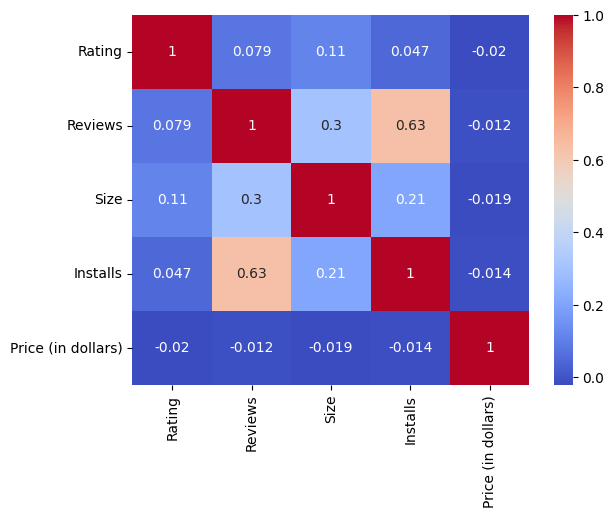

In [ ]:
corr =df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.plot()

In [ ]:
df['Category'].value_counts()

,count
Category,
GAME,507
FAMILY,485
TOOLS,265
MEDICAL,265
PERSONALIZATION,198
DATING,187
HEALTH_AND_FITNESS,186
COMMUNICATION,180
PRODUCTIVITY,176


In [ ]:
df[df['Rating'].isnull()]['Category'].value_counts()

,count
Category,
MEDICAL,52
DATING,37
PERSONALIZATION,14
FAMILY,13
LIBRARIES_AND_DEMO,12
EVENTS,11
PARENTING,10
BOOKS_AND_REFERENCE,7
BEAUTY,6


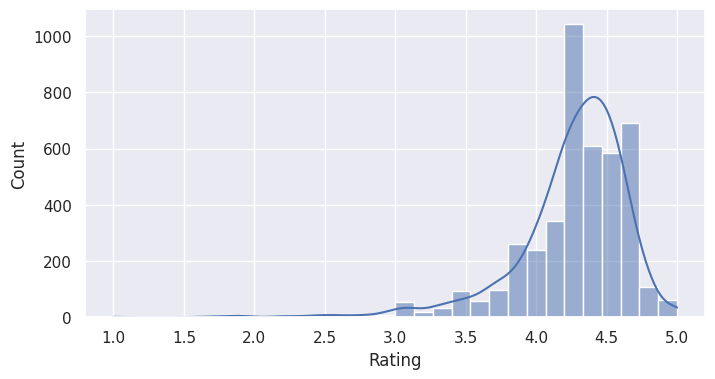

In [ ]:
sns.set(rc={'figure.figsize':(8,4)})
sns.histplot(df,x='Rating',kde=True,bins=30)
plt.show()

In [ ]:
rating_categorywise = df.groupby('Category')['Rating'].mean()
def replace_nan_in_rating(row):
  if (pd.isnull(row['Rating'])):
    return rating_categorywise[row['Category']]
  else:
    return row['Rating']

In [ ]:
df['Rating'] = df.apply(replace_nan_in_rating,axis=1)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Content Rating,Genres,Last Updated,Current Version,Android Version
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Everyone,Productivity,"September 27, 2016",2.0.1027,3.0 and up
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Everyone,Action,"February 24, 2016",1,2.3 and up
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Everyone,Casual,"October 20, 2017",Varies with device,Varies with device
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Everyone,Sports,"November 20, 2013",Varies with device,Varies with device


In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,1074
Installs,0
Price (in dollars),0
Content Rating,0
Genres,0
Last Updated,0


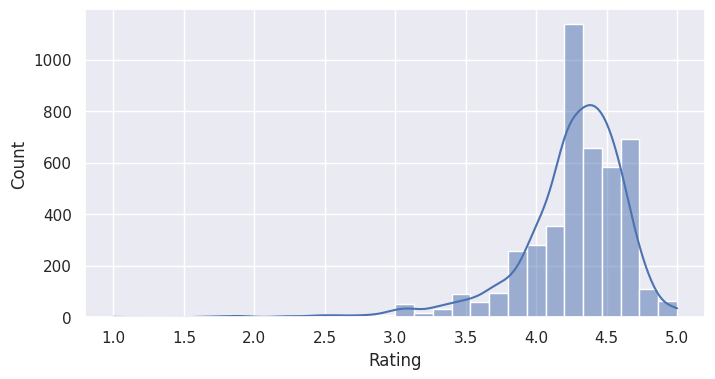

In [ ]:
sns.histplot(df,x='Rating',kde=True,bins=30)
plt.show()

In [ ]:
df.dropna(subset=['Current Version','Android Version'],inplace=True)

In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,1074
Installs,0
Price (in dollars),0
Content Rating,0
Genres,0
Last Updated,0


In [ ]:
df['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+'], dtype=object)

In [ ]:
df=pd.get_dummies(df,columns=['Content Rating'],dtype=int)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Last Updated,Current Version,Android Version,Content Rating_Adults only 18+,Content Rating_Everyone,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0,1,0,0,0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0,1,0,0,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0,1,0,0,0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0,0,0,0,1
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,"September 27, 2016",2.0.1027,3.0 and up,0,1,0,0,0
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,"February 24, 2016",1,2.3 and up,0,1,0,0,0
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,"October 20, 2017",Varies with device,Varies with device,0,1,0,0,0
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,"November 20, 2013",Varies with device,Varies with device,0,1,0,0,0


In [ ]:
df.rename(columns={'Content Rating_Everyone 10+':'Content_Rating_10+','Content Rating_Mature 17+':'Content_Rating_17+','Content Rating_Adults only 18+':'Content_Rating_18+'},inplace=True)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Last Updated,Current Version,Android Version,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0,1,0,0,0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0,1,0,0,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0,1,0,0,0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0,0,0,0,1
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,"September 27, 2016",2.0.1027,3.0 and up,0,1,0,0,0
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,"February 24, 2016",1,2.3 and up,0,1,0,0,0
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,"October 20, 2017",Varies with device,Varies with device,0,1,0,0,0
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,"November 20, 2013",Varies with device,Varies with device,0,1,0,0,0


In [ ]:
df['Genres'].unique()

array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [ ]:
df['Genres'].value_counts()

,count
Genres,
Medical,265
Tools,264
Personalization,196
Dating,187
Health & Fitness,186
...,...
Tools;Education,1
Parenting;Brain Games,1
Video Players & Editors;Music & Video,1


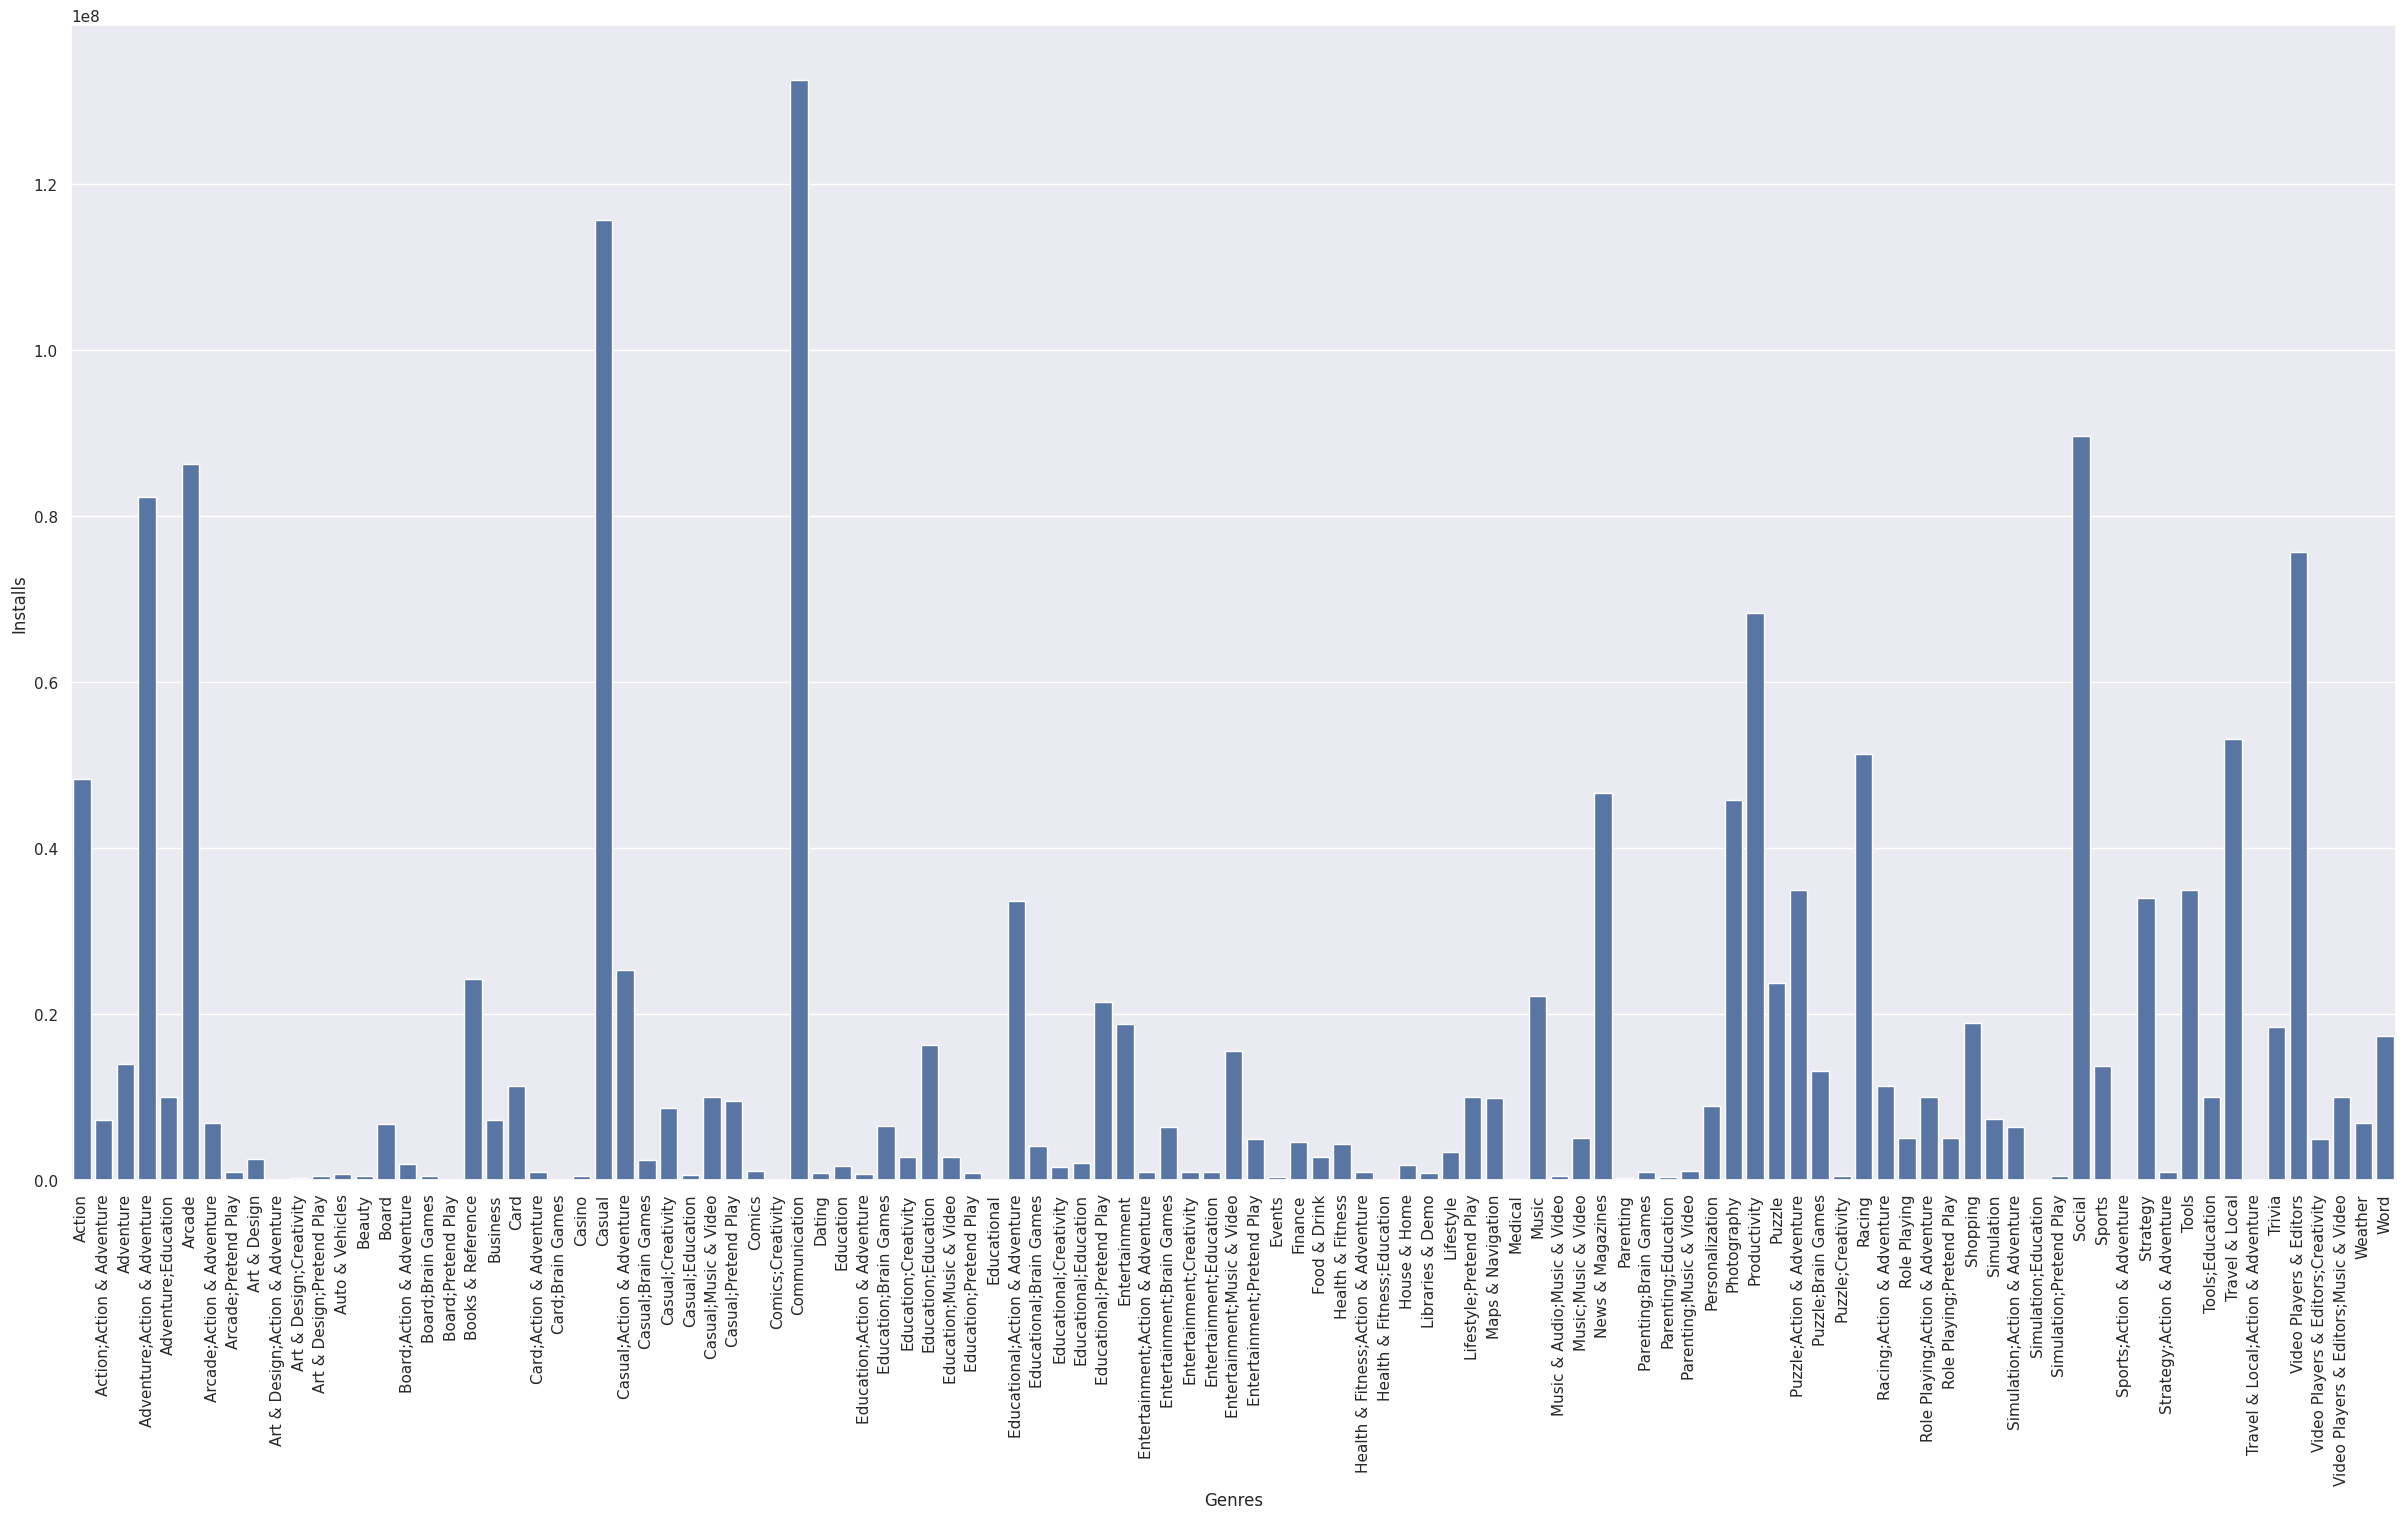

In [ ]:
sns.set(rc={'figure.figsize':(30,15)})
avg_installs_by_genres = df.groupby('Genres', as_index=False)['Installs'].mean()
sns.barplot(data=avg_installs_by_genres,x='Genres',y='Installs')
plt.xticks(rotation=90)
plt.show()

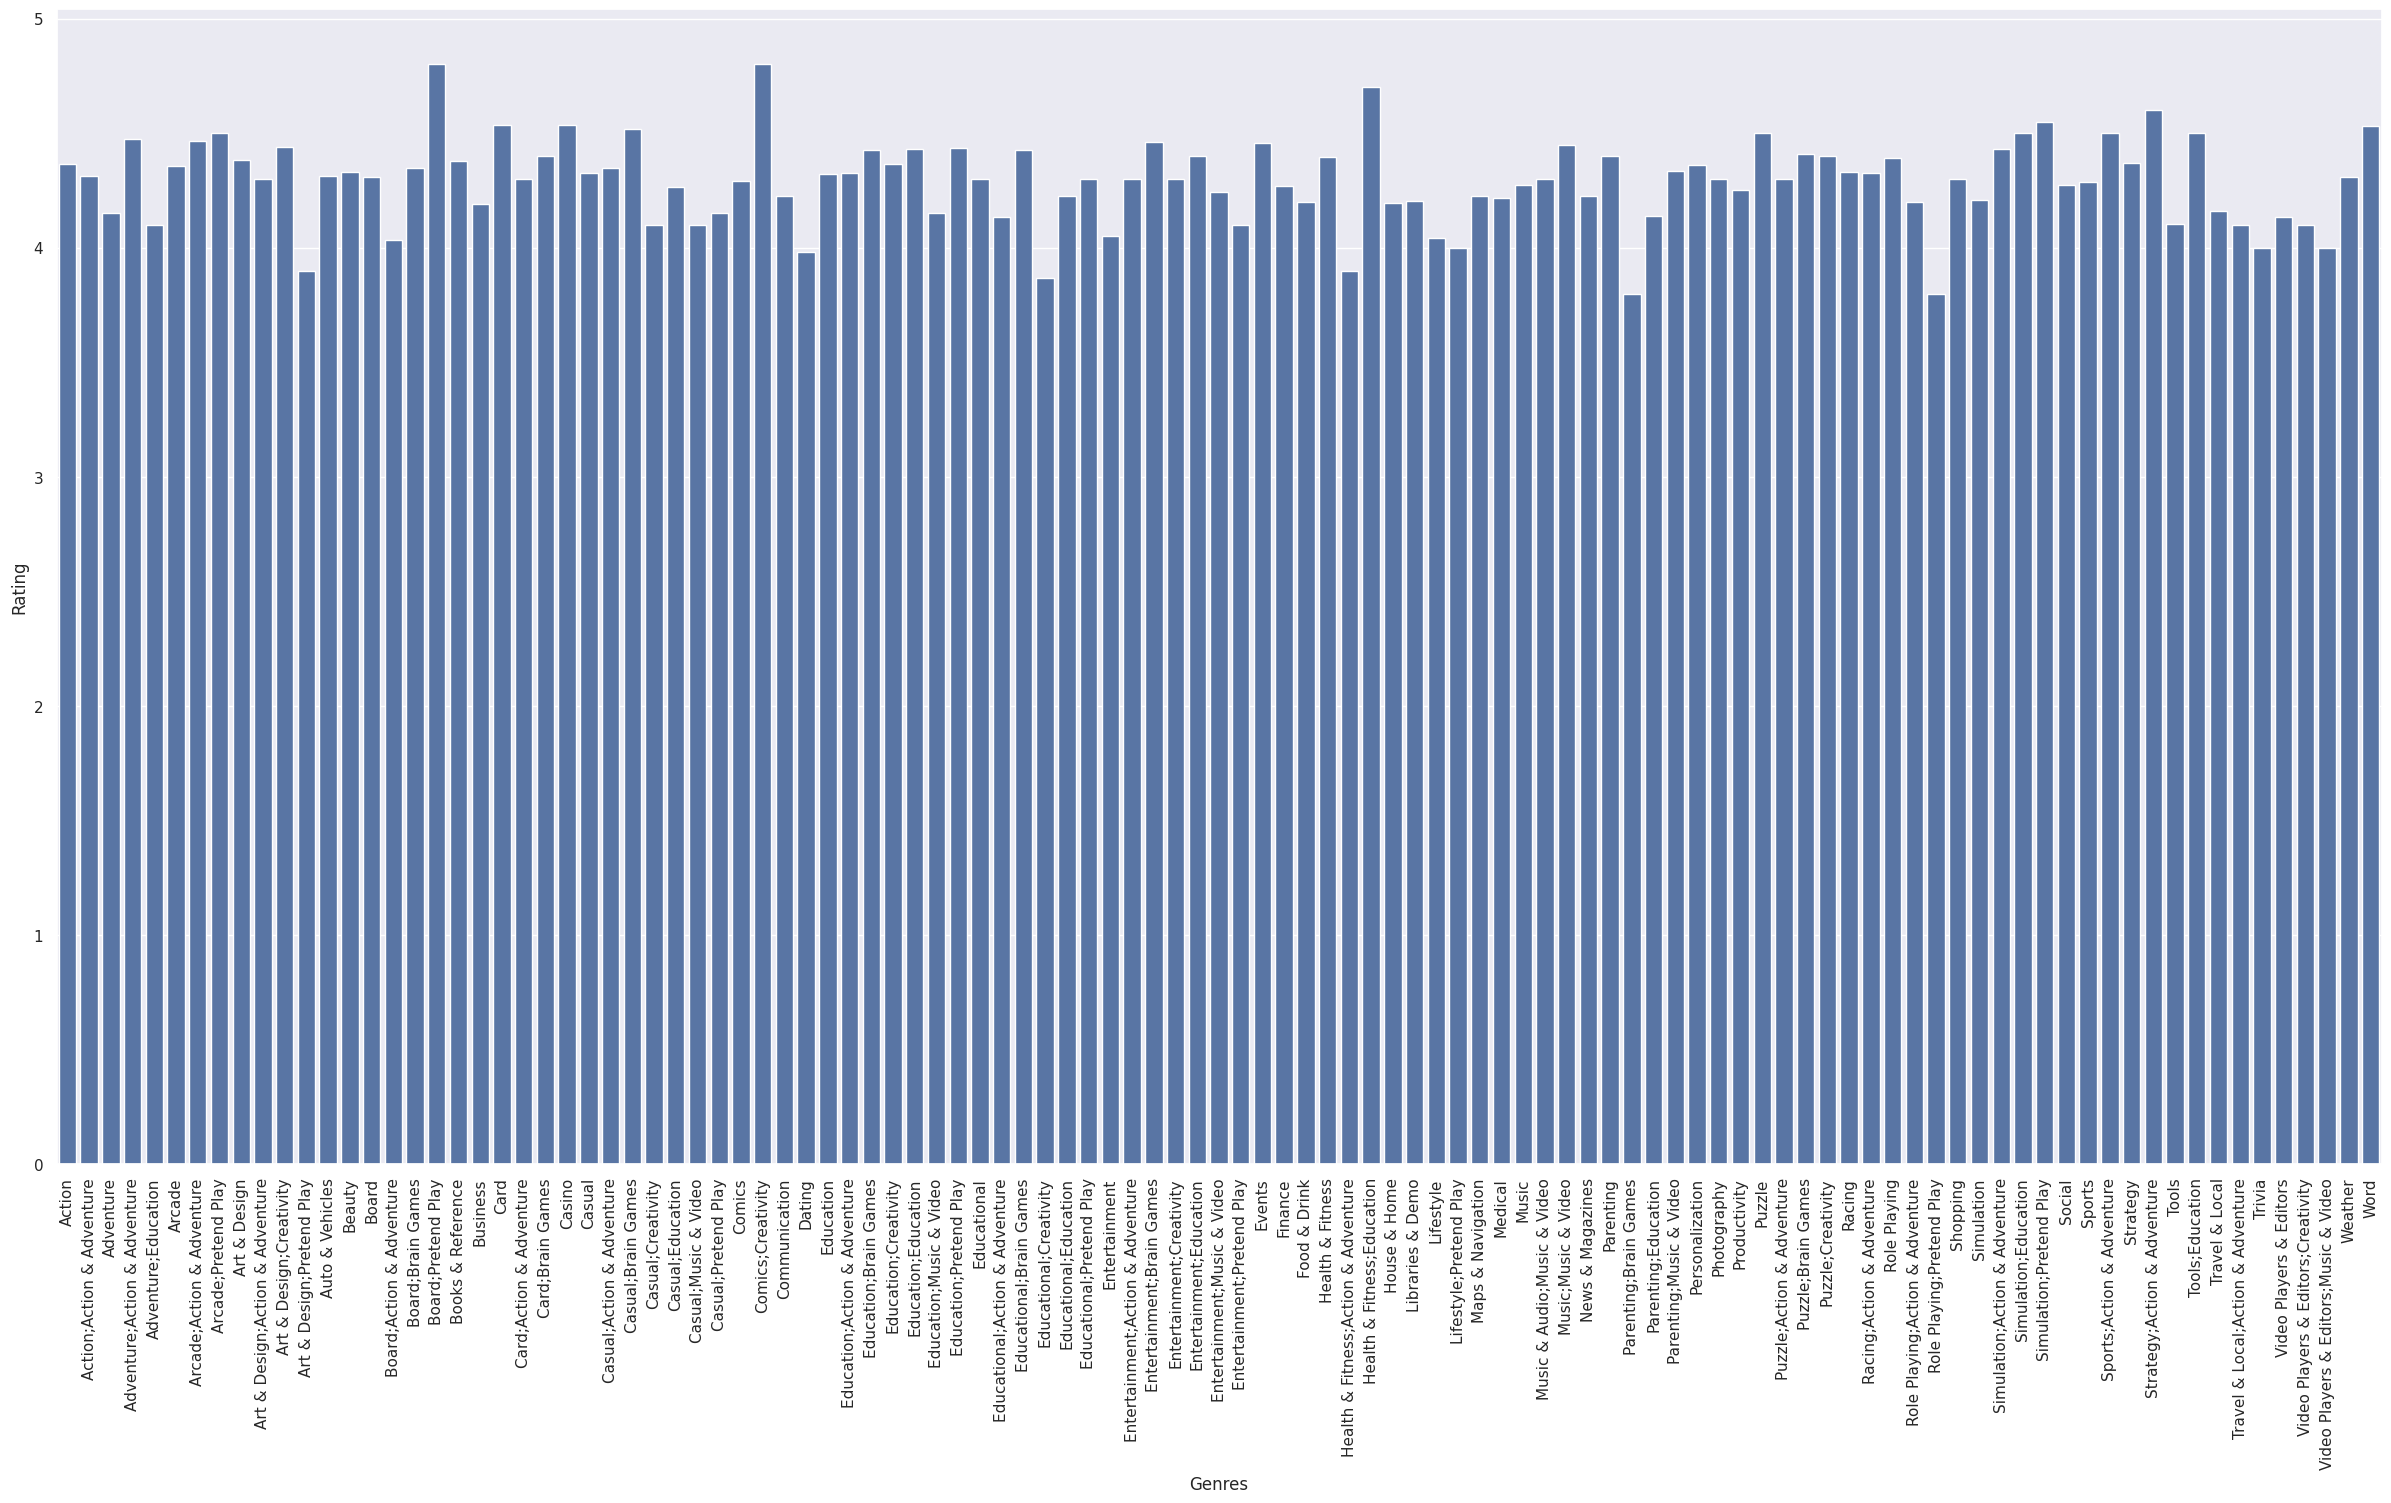

In [ ]:
df_temp = df.dropna(subset=['Rating'])
avg_rating_by_genres = df_temp.groupby('Genres', as_index=False)['Rating'].mean()
sns.barplot(data=avg_rating_by_genres,x='Genres',y='Rating')
plt.xticks(rotation=90)
plt.show()

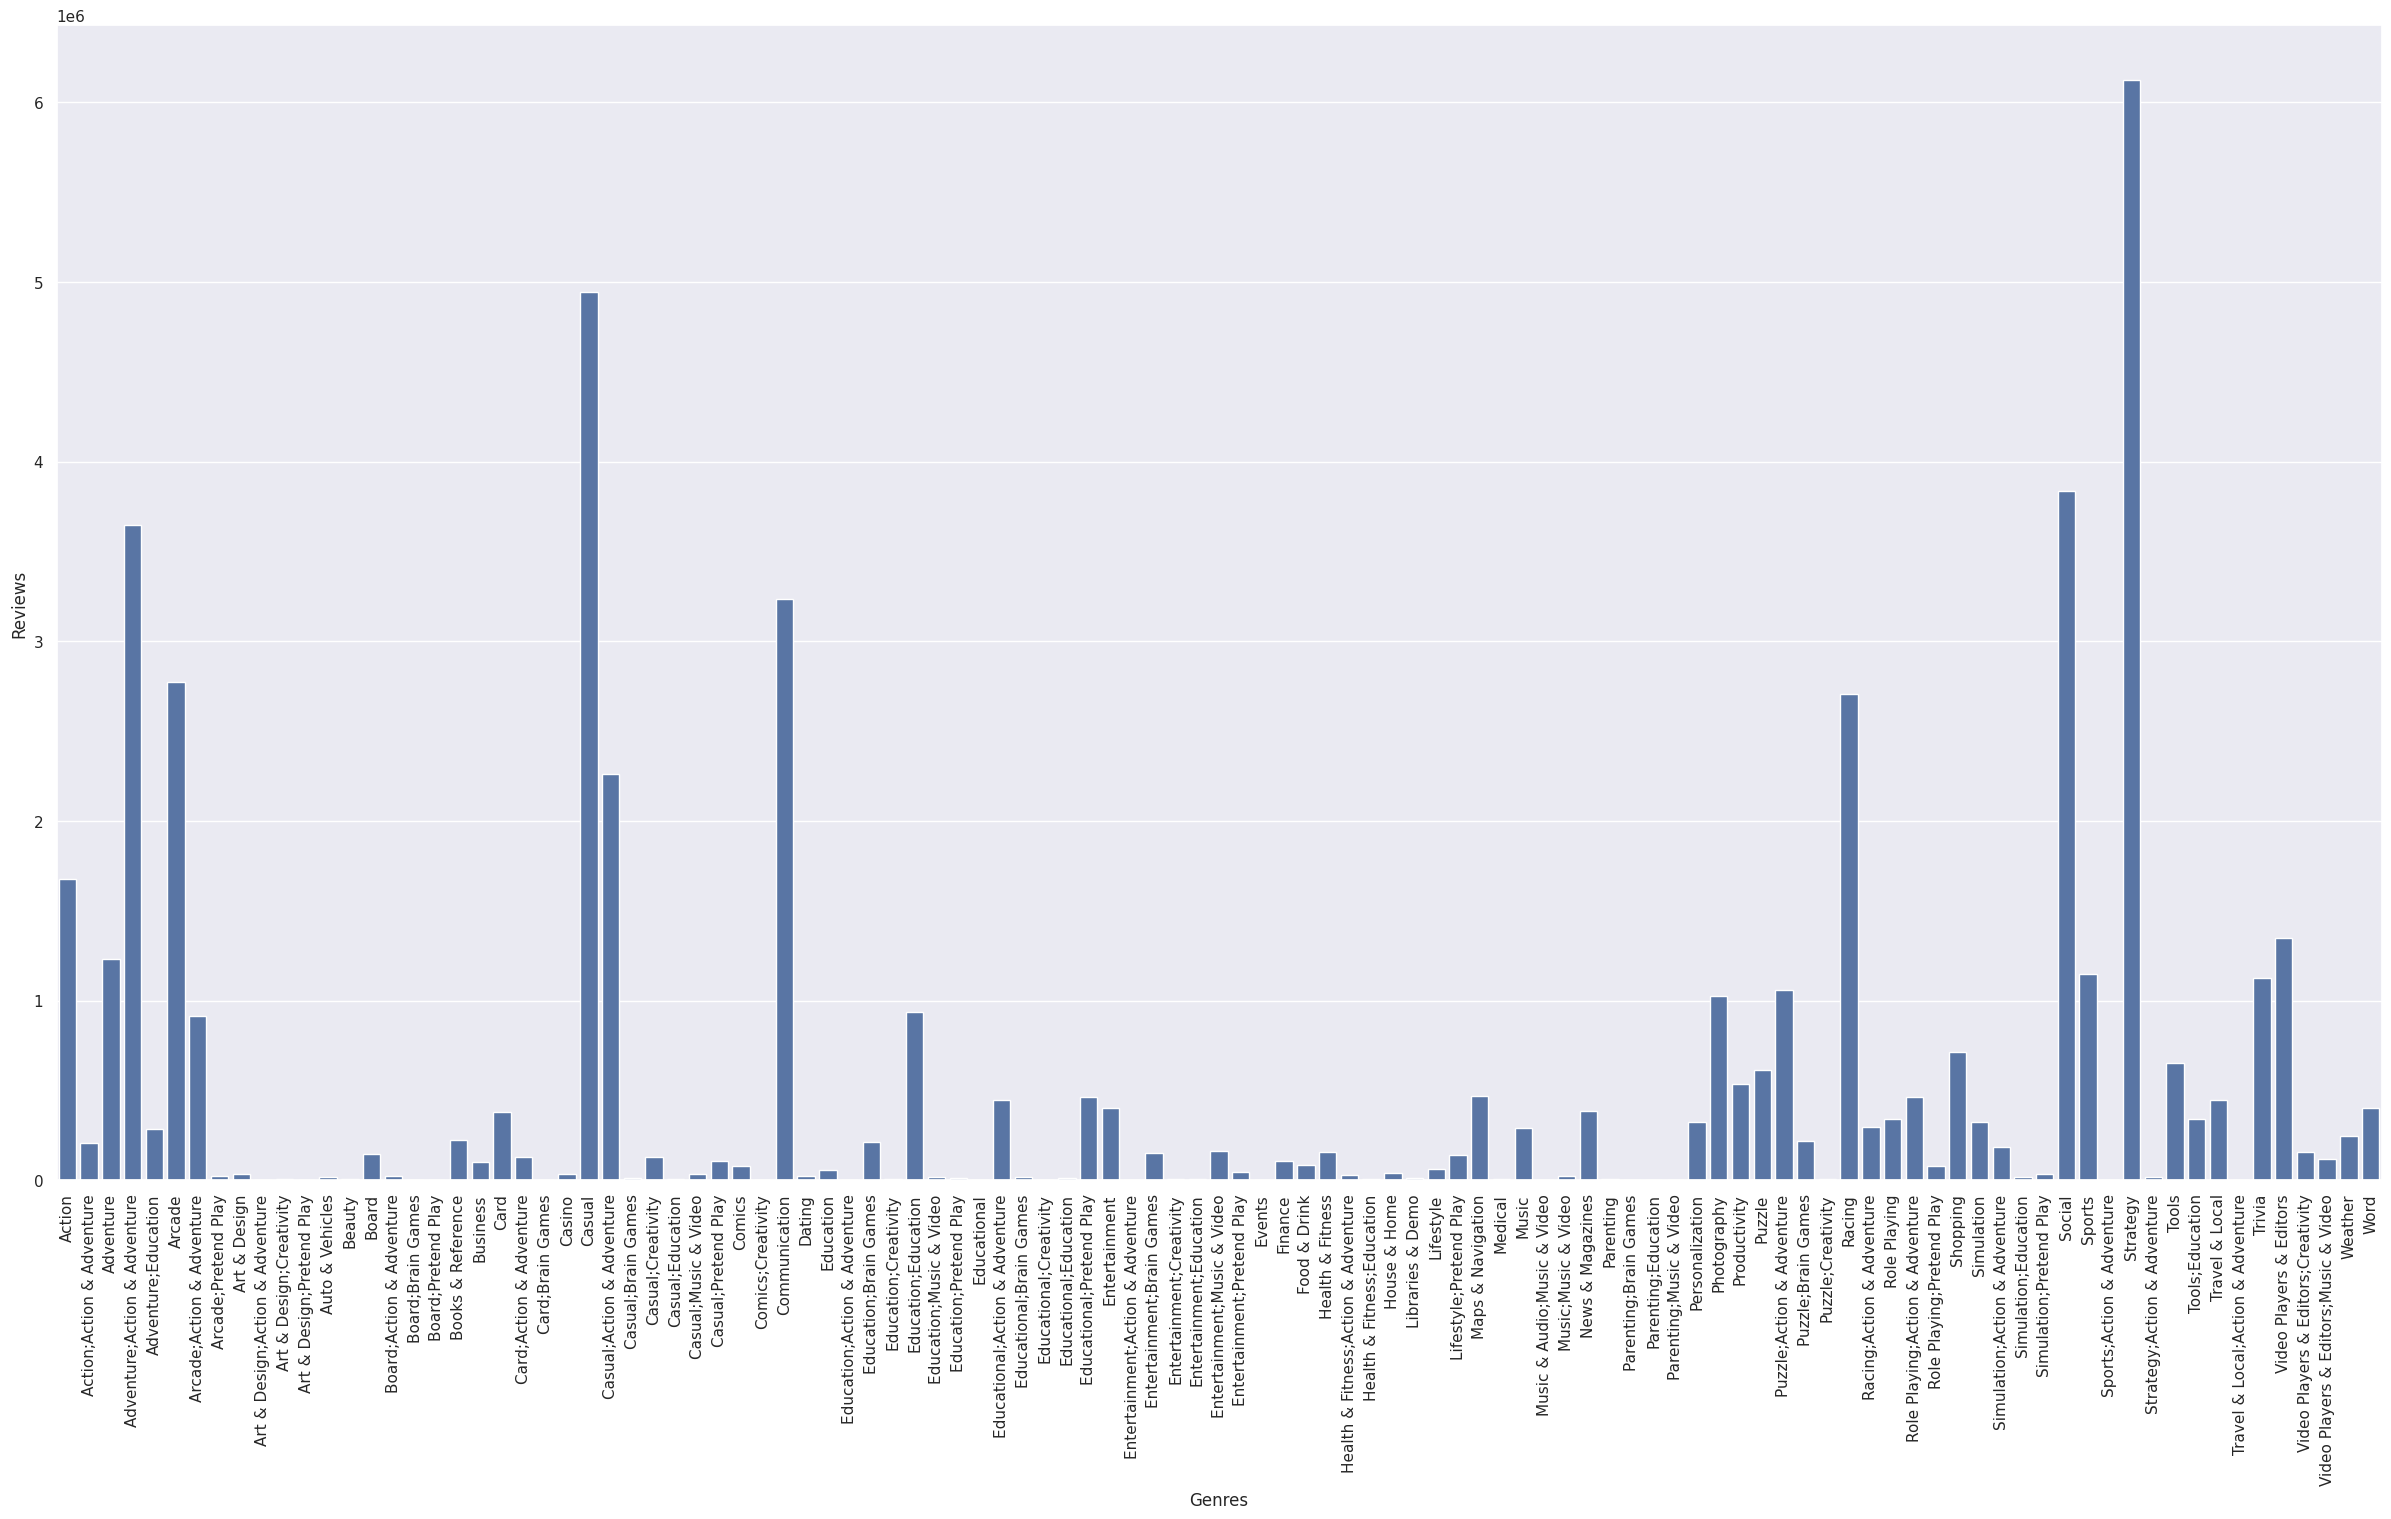

In [ ]:
avg_rating_by_genres = df.groupby('Genres', as_index=False)['Reviews'].mean()
sns.barplot(data=avg_rating_by_genres,x='Genres',y='Reviews')
plt.xticks(rotation=90)
plt.show()

In [ ]:
genres_installs = df.groupby('Genres')['Installs'].mean()
df['Genres_Installs_encoded'] = df['Genres'].map(genres_installs)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Last Updated,Current Version,Android Version,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0,1,0,0,0,2.548896e+06
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0,1,0,0,0,5.000000e+05
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0,1,0,0,0,2.548896e+06
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0,0,0,0,1,2.548896e+06
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0,1,0,0,0,2.420000e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,"September 27, 2016",2.0.1027,3.0 and up,0,1,0,0,0,6.833561e+07
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,"February 24, 2016",1,2.3 and up,0,1,0,0,0,4.831899e+07
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,"October 20, 2017",Varies with device,Varies with device,0,1,0,0,0,1.156919e+08
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,"November 20, 2013",Varies with device,Varies with device,0,1,0,0,0,1.383234e+07


In [ ]:
genres_ratings = df.groupby('Genres')['Rating'].mean()
df['Genres_Ratings_encoded'] = df['Genres'].map(genres_ratings)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Last Updated,Current Version,Android Version,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0,1,0,0,0,5.000000e+05,3.900000
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0,0,0,0,1,2.548896e+06,4.383333
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0,1,0,0,0,2.420000e+05,4.440000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,"September 27, 2016",2.0.1027,3.0 and up,0,1,0,0,0,6.833561e+07,4.251744
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,"February 24, 2016",1,2.3 and up,0,1,0,0,0,4.831899e+07,4.366197
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,"October 20, 2017",Varies with device,Varies with device,0,1,0,0,0,1.156919e+08,4.326087
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,"November 20, 2013",Varies with device,Varies with device,0,1,0,0,0,1.383234e+07,4.285105


In [ ]:
genres_reviews = df.groupby('Genres')['Reviews'].mean()
df['Genres_Reviews_encoded'] = df['Genres'].map(genres_reviews)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Last Updated,Current Version,Android Version,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0,1,0,0,0,5.000000e+05,3.900000,9.705000e+02
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0,0,0,0,1,2.548896e+06,4.383333,3.501562e+04
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0,1,0,0,0,2.420000e+05,4.440000,6.339800e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,"September 27, 2016",2.0.1027,3.0 and up,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,"February 24, 2016",1,2.3 and up,0,1,0,0,0,4.831899e+07,4.366197,1.677944e+06
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,"October 20, 2017",Varies with device,Varies with device,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,"November 20, 2013",Varies with device,Varies with device,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06


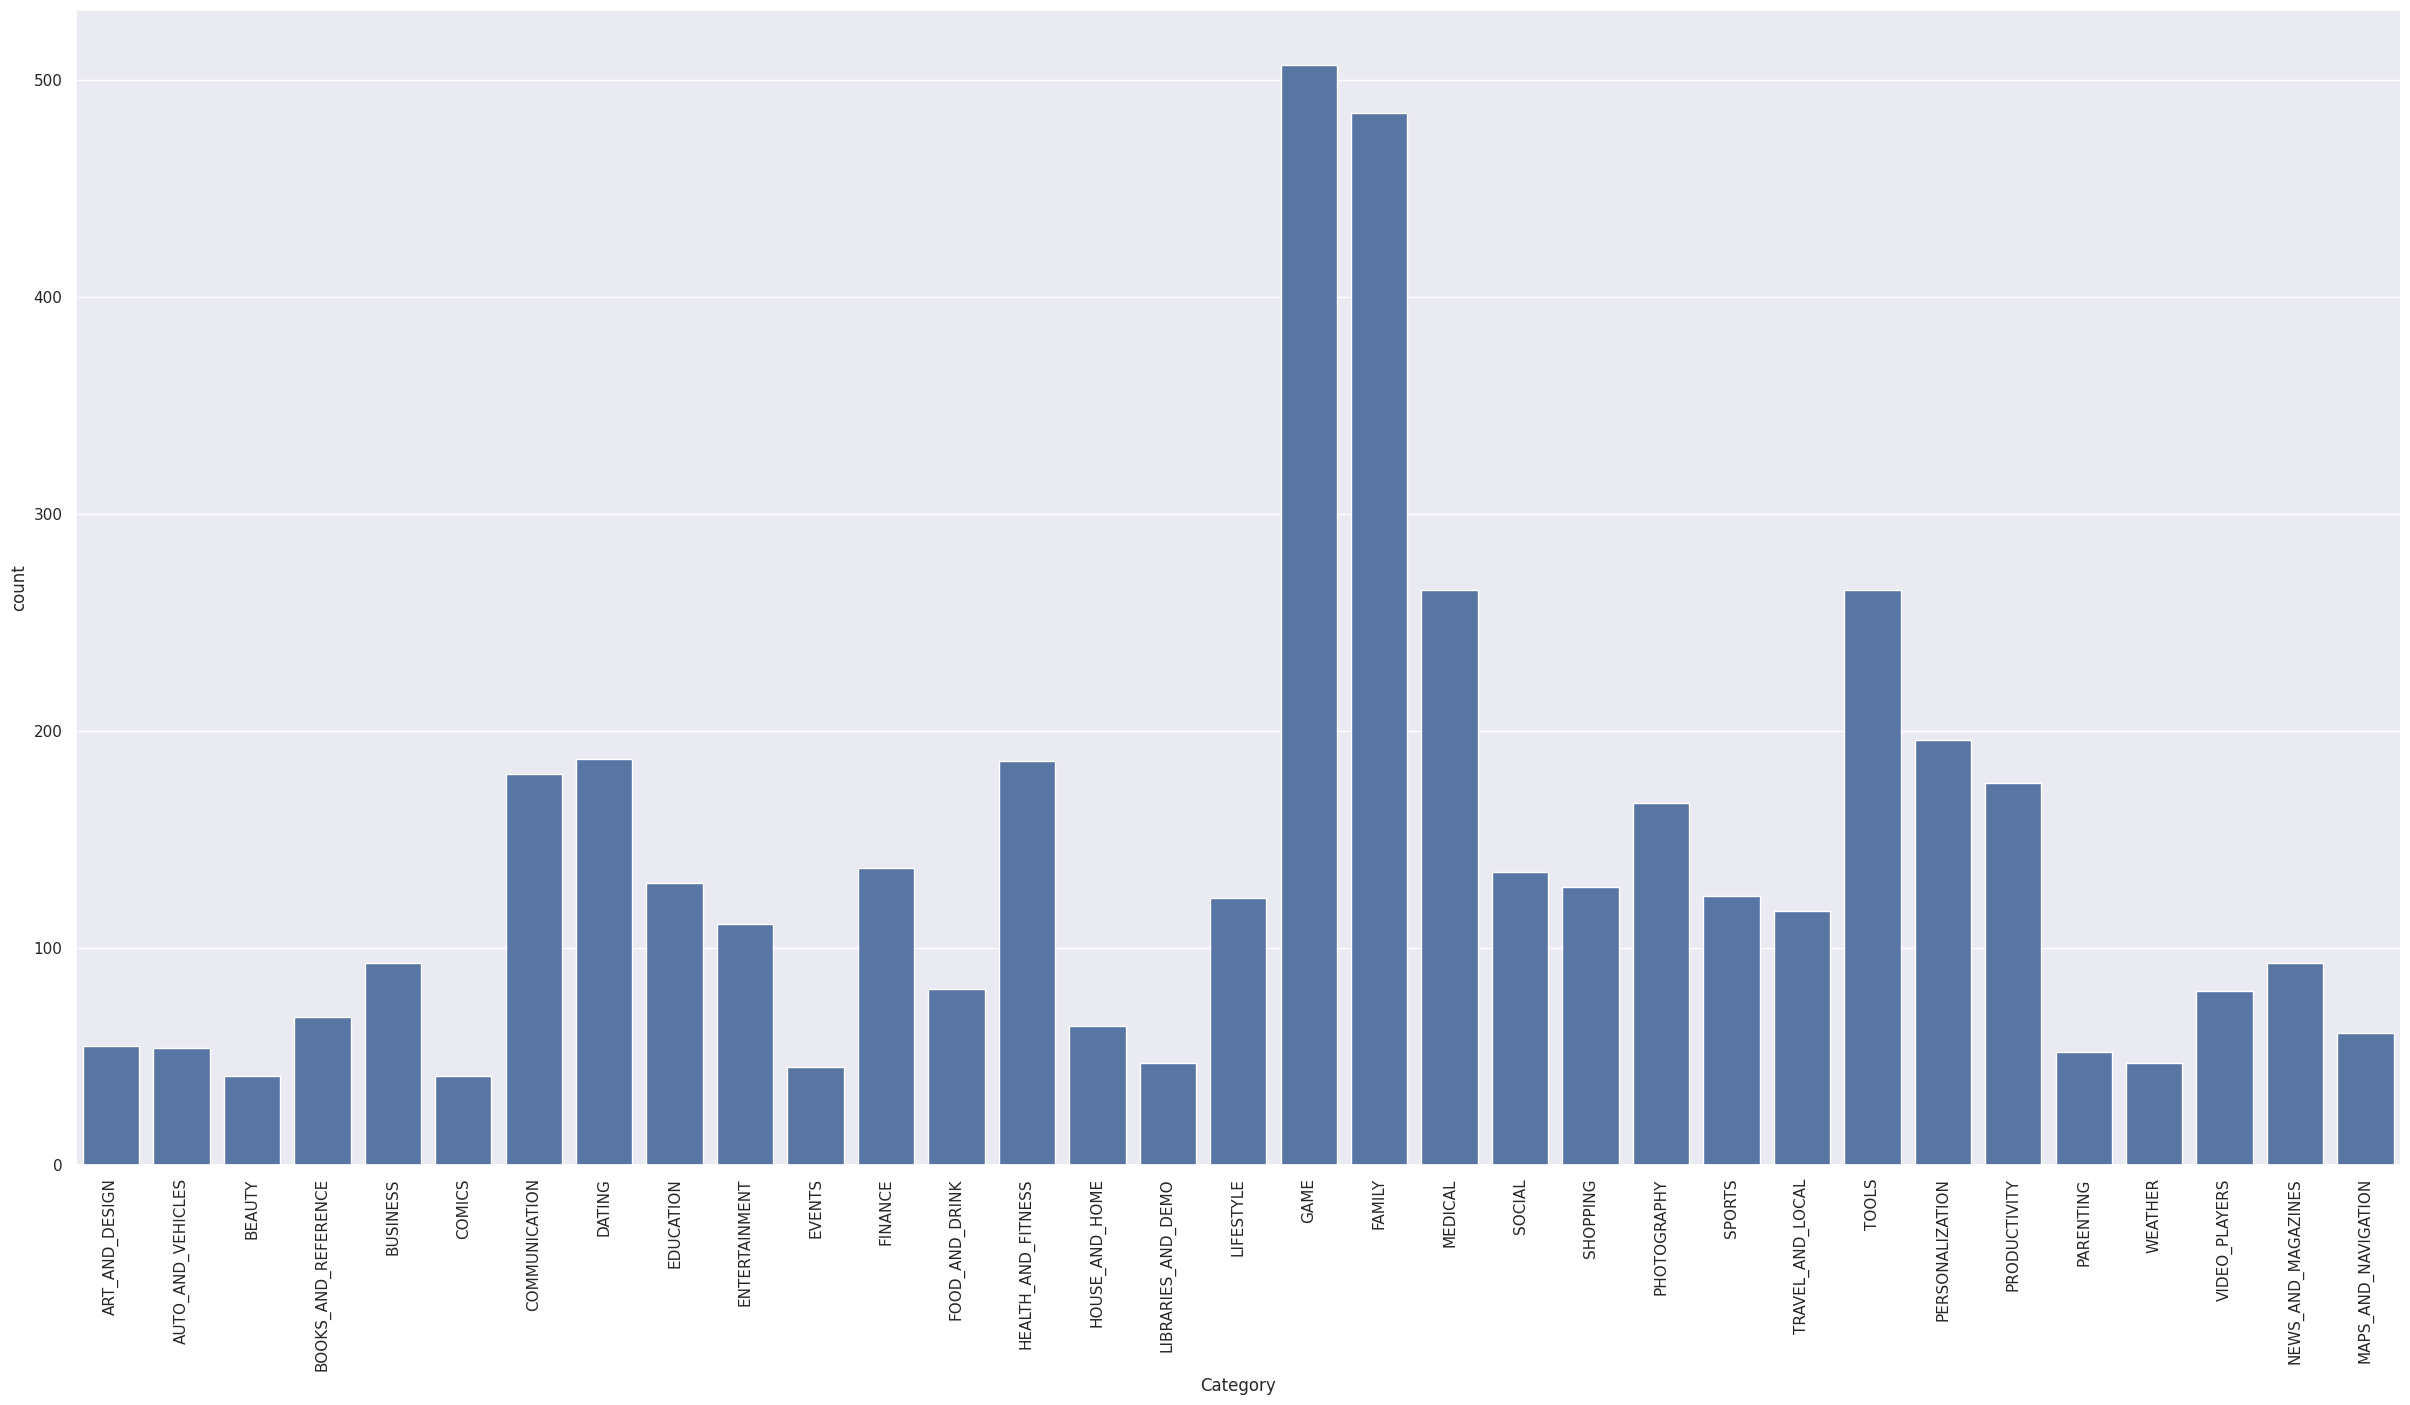

In [ ]:
sns.countplot(df,x='Category')
plt.xticks(rotation=90)
plt.show()

In [ ]:
category_installs = df.groupby('Category')['Installs'].mean()
df['Category_Installs_encoded'] = df['Category'].map(category_installs)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Last Updated,Current Version,Android Version,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0,1,0,0,0,5.000000e+05,3.900000,9.705000e+02,2.257400e+06
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0,0,0,0,1,2.548896e+06,4.383333,3.501562e+04,2.257400e+06
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0,1,0,0,0,2.420000e+05,4.440000,6.339800e+03,2.257400e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,"September 27, 2016",2.0.1027,3.0 and up,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05,6.833561e+07
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,"February 24, 2016",1,2.3 and up,0,1,0,0,0,4.831899e+07,4.366197,1.677944e+06,5.649276e+07
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,"October 20, 2017",Varies with device,Varies with device,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,1.294803e+07
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,"November 20, 2013",Varies with device,Varies with device,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06


In [ ]:
category_rating = df.groupby('Category')['Rating'].mean()
df['Category_Rating_encoded'] = df['Category'].map(category_rating)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Last Updated,Current Version,...,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,"January 7, 2018",1.0.0,...,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,...,0,1,0,0,0,5.000000e+05,3.900000,9.705000e+02,2.257400e+06,4.379240
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,"August 1, 2018",1.2.4,...,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,"June 8, 2018",Varies with device,...,0,0,0,0,1,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,"June 20, 2018",1.1,...,0,1,0,0,0,2.420000e+05,4.440000,6.339800e+03,2.257400e+06,4.379240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,"September 27, 2016",2.0.1027,...,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05,6.833561e+07,4.251744
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,"February 24, 2016",1,...,0,1,0,0,0,4.831899e+07,4.366197,1.677944e+06,5.649276e+07,4.381076
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,"October 20, 2017",Varies with device,...,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,1.294803e+07,4.238559
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,"November 20, 2013",Varies with device,...,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06,4.259350


In [ ]:
pd.set_option('display.max_columns', None)
category_reviews = df.groupby('Category')['Reviews'].mean()
df['Category_Reviews_encoded'] = df['Category'].map(category_reviews)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Last Updated,Current Version,Android Version,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0,1,0,0,0,5.000000e+05,3.900000,9.705000e+02,2.257400e+06,4.379240,3.115413e+04
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0,0,0,0,1,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0,1,0,0,0,2.420000e+05,4.440000,6.339800e+03,2.257400e+06,4.379240,3.115413e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,"September 27, 2016",2.0.1027,3.0 and up,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05,6.833561e+07,4.251744,5.384339e+05
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,"February 24, 2016",1,2.3 and up,0,1,0,0,0,4.831899e+07,4.366197,1.677944e+06,5.649276e+07,4.381076,2.566874e+06
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,"October 20, 2017",Varies with device,Varies with device,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,1.294803e+07,4.238559,5.741305e+05
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,"November 20, 2013",Varies with device,Varies with device,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06,4.259350,3.293917e+05


In [ ]:
pd.to_datetime(df['Last Updated'])

,Last Updated
0,2018-01-07
1,2018-01-15
2,2018-08-01
3,2018-06-08
4,2018-06-20
...,...
4995,2016-09-27
4996,2016-02-24
4997,2017-10-20
4998,2013-11-20


In [ ]:
df['Last_Updated_Year'] = pd.to_datetime(df['Last Updated']).dt.year
df['Last_Updated_Month'] = pd.to_datetime(df['Last Updated']).dt.month
df['Last_Updated_Day'] = pd.to_datetime(df['Last Updated']).dt.day
df.drop(columns=['Last Updated'],inplace=True)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Current Version,Android Version,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,1.0.0,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,2.0.0,4.0.3 and up,0,1,0,0,0,5.000000e+05,3.900000,9.705000e+02,2.257400e+06,4.379240,3.115413e+04,2018,1,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,1.2.4,4.0.3 and up,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,8,1
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,Varies with device,4.2 and up,0,0,0,0,1,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,6,8
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,1.1,4.4 and up,0,1,0,0,0,2.420000e+05,4.440000,6.339800e+03,2.257400e+06,4.379240,3.115413e+04,2018,6,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,2.0.1027,3.0 and up,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05,6.833561e+07,4.251744,5.384339e+05,2016,9,27
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,1,2.3 and up,0,1,0,0,0,4.831899e+07,4.366197,1.677944e+06,5.649276e+07,4.381076,2.566874e+06,2016,2,24
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,Varies with device,Varies with device,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,1.294803e+07,4.238559,5.741305e+05,2017,10,20
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,Varies with device,Varies with device,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06,4.259350,3.293917e+05,2013,11,20


In [ ]:
df.groupby('Current Version')['Rating'].mean().sort_values()

,Rating
Current Version,
4.1.07,1.7
1.91,1.8
6.3.7,1.9
2.0.1027,1.9
02.02.0045,2.2
...,...
v2018.May.15.14,5.0
0.1,5.0
1.0.32,5.0


In [ ]:
df.groupby('Current Version')['Reviews'].mean().sort_values()

,Reviews
Current Version,
1.0.10,0.000000e+00
1.0 Super Ear Hearing,0.000000e+00
2.0.0 (35717),0.000000e+00
Initial,0.000000e+00
5.5.8,0.000000e+00
...,...
4.8.0.132,1.488964e+07
12.8.5.1121,1.771389e+07
1.129.0.2,2.242690e+07


In [ ]:
android_rating = df.groupby('Android Version')['Rating'].mean().sort_values()

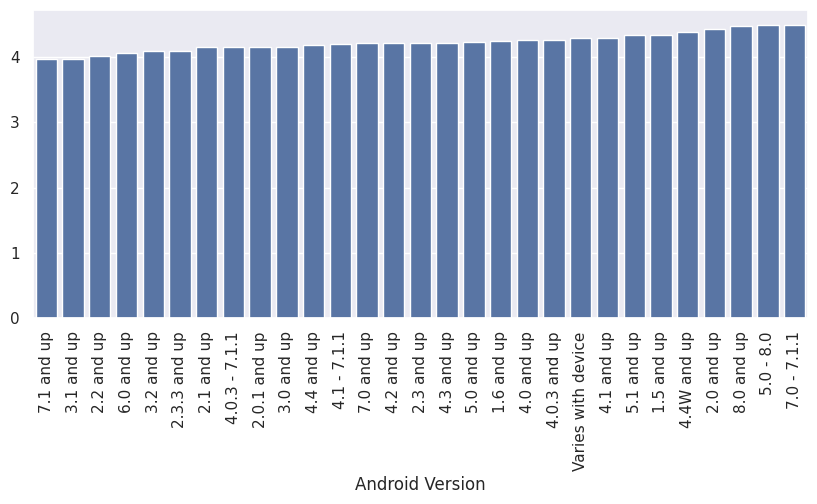

In [ ]:
sns.set(rc={'figure.figsize':(10,4)})
sns.barplot(x=android_rating.index,y=android_rating.values)
plt.xticks(rotation=90)
plt.show()

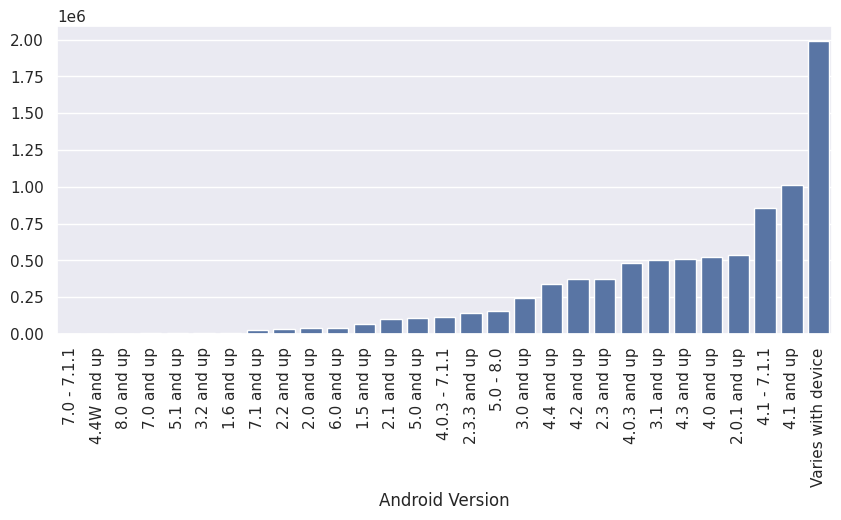

In [ ]:
android_reviews = df.groupby('Android Version')['Reviews'].mean().sort_values()
sns.barplot(x=android_reviews.index,y=android_reviews.values)
plt.xticks(rotation=90)
plt.show()

No trend is observed from current version and android version. So, dropping those columns

In [ ]:
df.drop(columns=['Current Version','Android Version'],inplace=True)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,0,1,0,0,0,5.000000e+05,3.900000,9.705000e+02,2.257400e+06,4.379240,3.115413e+04,2018,1,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,8,1
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,0,0,0,0,1,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,6,8
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,0,1,0,0,0,2.420000e+05,4.440000,6.339800e+03,2.257400e+06,4.379240,3.115413e+04,2018,6,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05,6.833561e+07,4.251744,5.384339e+05,2016,9,27
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,0,1,0,0,0,4.831899e+07,4.366197,1.677944e+06,5.649276e+07,4.381076,2.566874e+06,2016,2,24
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,NaN,100000,0.0,Casual,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,1.294803e+07,4.238559,5.741305e+05,2017,10,20
4998,AE Basketball,SPORTS,4.0,8100,NaN,1000000,0.0,Sports,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06,4.259350,3.293917e+05,2013,11,20


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4541 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   App                        4541 non-null   object 
 1   Category                   4541 non-null   object 
 2   Rating                     4541 non-null   float64
 3   Reviews                    4541 non-null   int64  
 4   Size                       3467 non-null   float64
 5   Installs                   4541 non-null   int64  
 6   Price (in dollars)         4541 non-null   float64
 7   Genres                     4541 non-null   object 
 8   Content_Rating_18+         4541 non-null   int64  
 9   Content Rating_Everyone    4541 non-null   int64  
 10  Content_Rating_10+         4541 non-null   int64  
 11  Content_Rating_17+         4541 non-null   int64  
 12  Content Rating_Teen        4541 non-null   int64  
 13  Genres_Installs_encoded    4541 non-null   float64
 1

In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,1074
Installs,0
Price (in dollars),0
Genres,0
Content_Rating_18+,0
Content Rating_Everyone,0


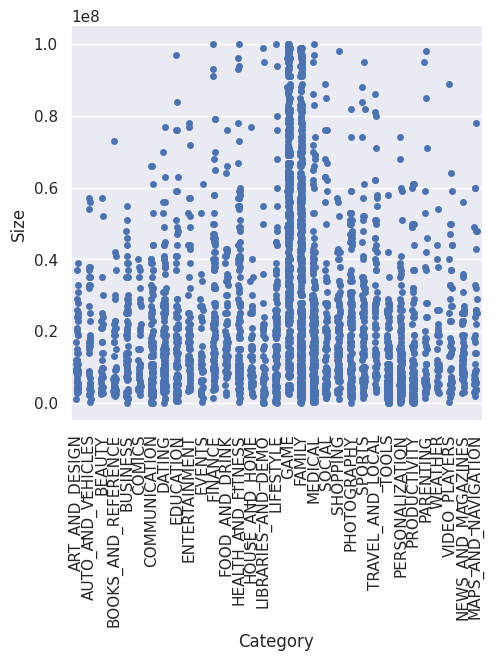

In [ ]:
sns.catplot(df,x='Category',y='Size')
plt.xticks(rotation=90)
plt.show()

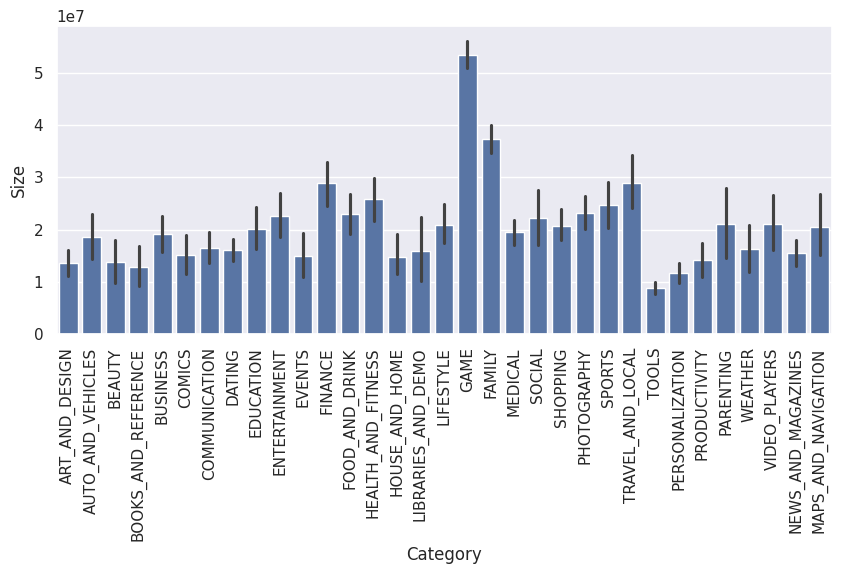

In [ ]:
sns.barplot(df,x='Category',y='Size')
plt.xticks(rotation=90)
plt.show()

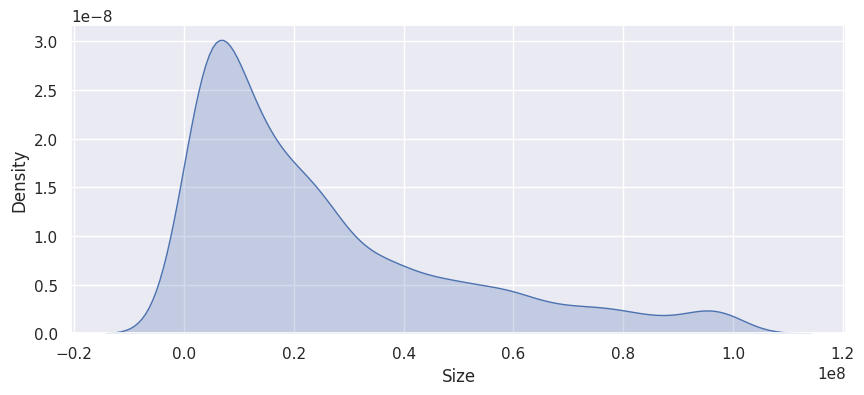

In [ ]:
sns.kdeplot(df,x='Size',fill=True)
plt.show()

In [ ]:
size_category = df.groupby('Category')['Size'].median()
def fill_size(row):
  if(pd.isnull(row['Size'])):
    return size_category[row['Category']]
  else:
    return row['Size']

In [ ]:
df['Size'] = df.apply(fill_size,axis=1)
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,0,1,0,0,0,5.000000e+05,3.900000,9.705000e+02,2.257400e+06,4.379240,3.115413e+04,2018,1,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,8,1
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,0,0,0,0,1,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,6,8
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,0,1,0,0,0,2.420000e+05,4.440000,6.339800e+03,2.257400e+06,4.379240,3.115413e+04,2018,6,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05,6.833561e+07,4.251744,5.384339e+05,2016,9,27
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,0,1,0,0,0,4.831899e+07,4.366197,1.677944e+06,5.649276e+07,4.381076,2.566874e+06,2016,2,24
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,30000000.0,100000,0.0,Casual,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,1.294803e+07,4.238559,5.741305e+05,2017,10,20
4998,AE Basketball,SPORTS,4.0,8100,20000000.0,1000000,0.0,Sports,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06,4.259350,3.293917e+05,2013,11,20


In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Price (in dollars),0
Genres,0
Content_Rating_18+,0
Content Rating_Everyone,0


In [ ]:
df_1 = df[df['Reviews'] > df['Installs']]
df_1

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
2454,KBA-EZ Health Guide,MEDICAL,5.000000,4,25000000.0,1,0.00,Medical,0,1,0,0,0,1.437850e+05,4.217371,4996.226415,1.437850e+05,4.217371,4996.226415,2018,8,2
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,FAMILY,4.238559,4,64000000.0,1,0.00,Education,0,1,0,0,0,1.687196e+06,4.320018,57143.765060,1.294803e+07,4.238559,574130.509278,2018,7,17
4663,Alarmy (Sleep If U Can) - Pro,LIFESTYLE,4.800000,10249,15000000.0,10000,2.49,Lifestyle,0,1,0,0,0,3.380910e+06,4.043799,64325.983607,3.434724e+06,4.043443,64949.308943,2018,7,30


In [ ]:
df = df[df['Reviews'] <= df['Installs']]
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,0.0,Art & Design,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,0.0,Art & Design;Pretend Play,0,1,0,0,0,5.000000e+05,3.900000,9.705000e+02,2.257400e+06,4.379240,3.115413e+04,2018,1,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,0.0,Art & Design,0,1,0,0,0,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,8,1
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,0.0,Art & Design,0,0,0,0,1,2.548896e+06,4.383333,3.501562e+04,2.257400e+06,4.379240,3.115413e+04,2018,6,8
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,0.0,Art & Design;Creativity,0,1,0,0,0,2.420000e+05,4.440000,6.339800e+03,2.257400e+06,4.379240,3.115413e+04,2018,6,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ESS Mobile for AE,PRODUCTIVITY,1.9,63,1800000.0,5000,0.0,Productivity,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05,6.833561e+07,4.251744,5.384339e+05,2016,9,27
4996,AE Jewels 2: Island Adventures,GAME,4.2,652,30000000.0,10000,0.0,Action,0,1,0,0,0,4.831899e+07,4.366197,1.677944e+06,5.649276e+07,4.381076,2.566874e+06,2016,2,24
4997,AE Bubble:Offline Bubble Games,FAMILY,4.2,6973,30000000.0,100000,0.0,Casual,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,1.294803e+07,4.238559,5.741305e+05,2017,10,20
4998,AE Basketball,SPORTS,4.0,8100,20000000.0,1000000,0.0,Sports,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06,4.259350,3.293917e+05,2013,11,20


[]

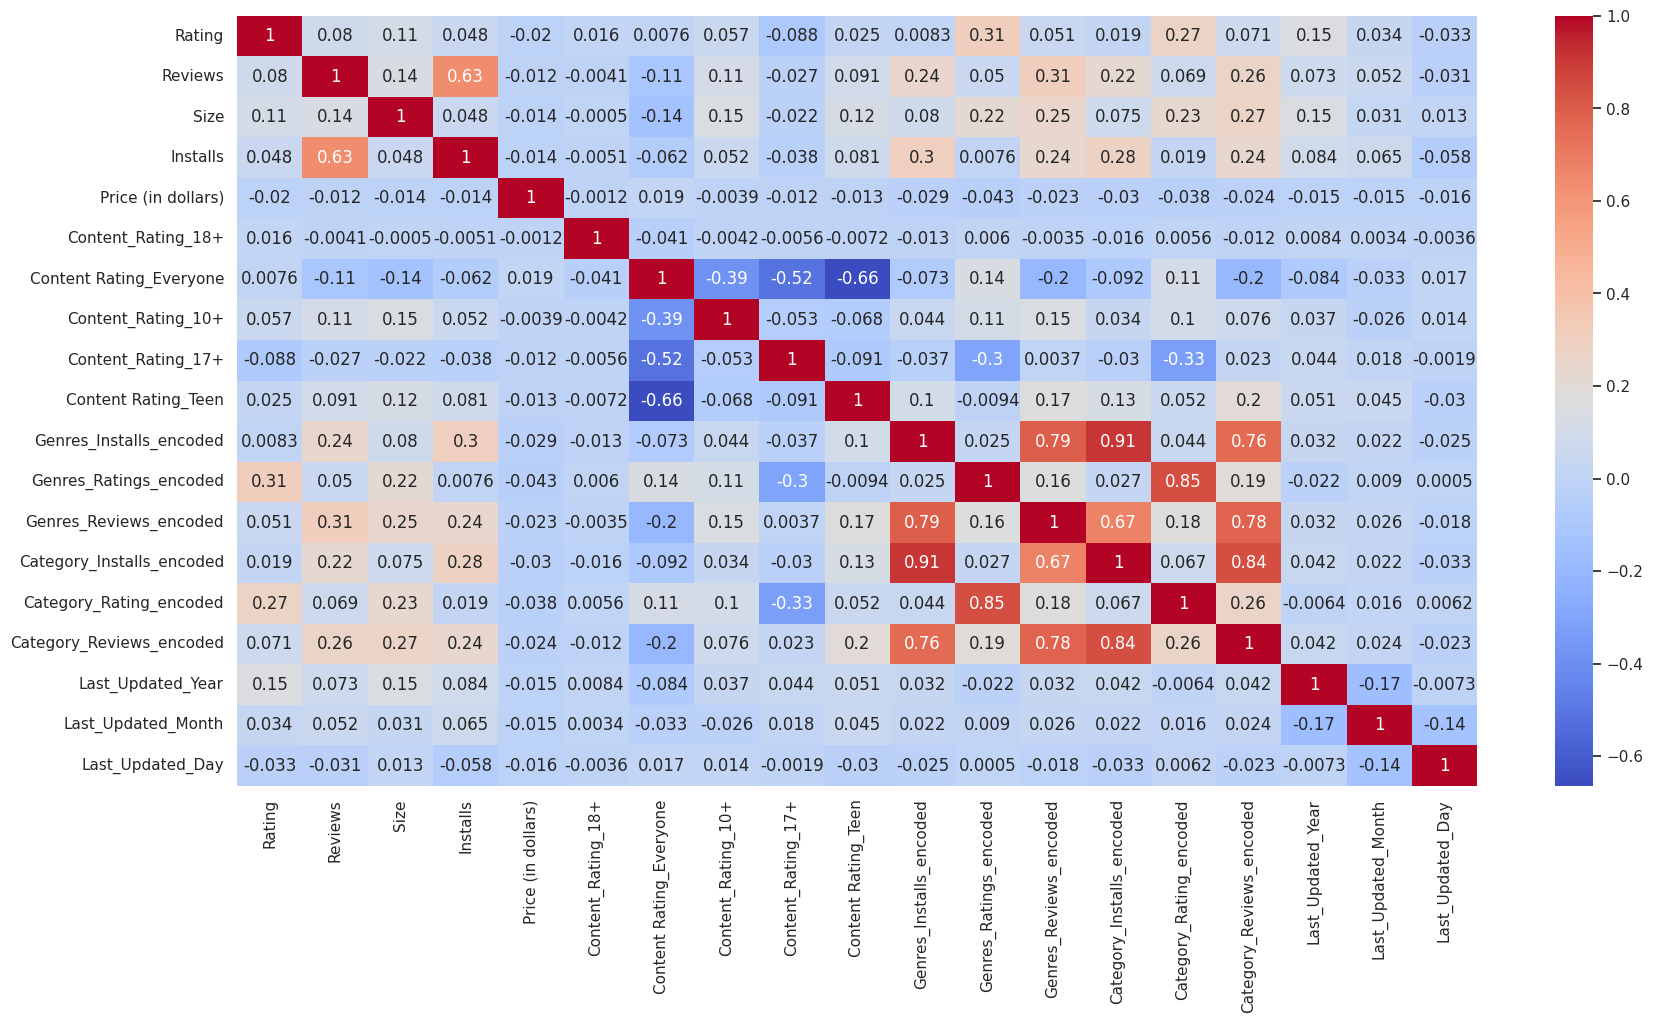

In [ ]:
sns.set(rc={'figure.figsize':(20,10)})
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.plot()

HANDLING OUTLIERS

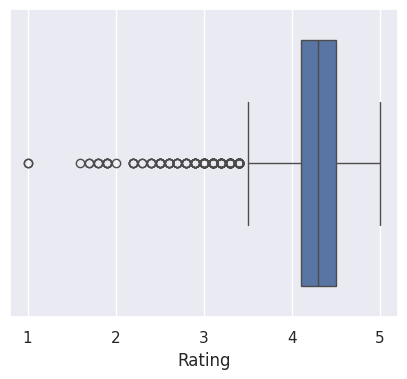

In [ ]:
sns.set(rc={'figure.figsize':(5,4)})
sns.boxplot(df,x='Rating')
plt.show()

Capping extreme values that might affect model performance

In [ ]:
df['Rating'].replace(1.0,1.5,inplace=True)

/tmp/ipython-input-70-78261342.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].replace(1.0,1.5,inplace=True)
/tmp/ipython-input-70-78261342.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating'].replace(1.0,1.5,inplace=True)


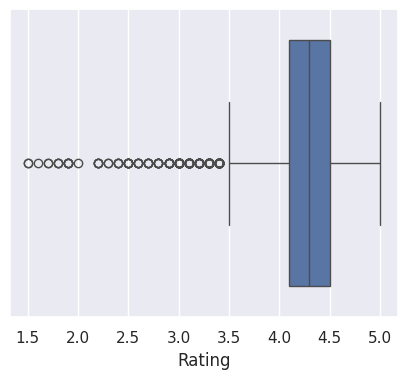

In [ ]:
sns.boxplot(df,x='Rating')
plt.show()

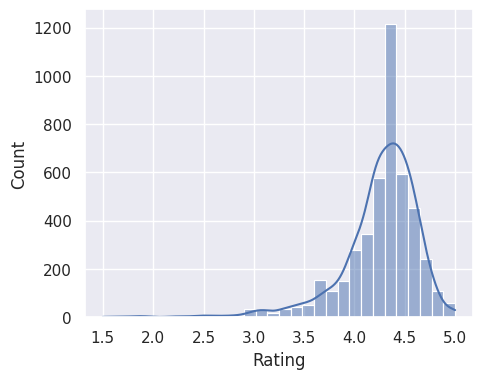

In [ ]:
sns.histplot(df,x='Rating',kde=True,bins=30)
plt.show()

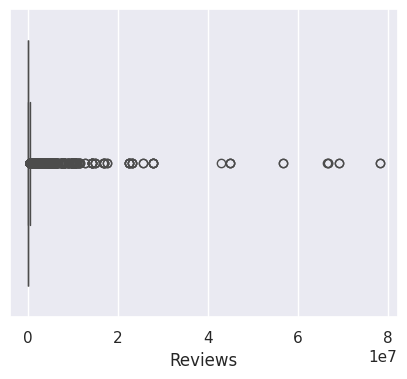

In [ ]:
sns.boxplot(df,x='Reviews')
plt.show()

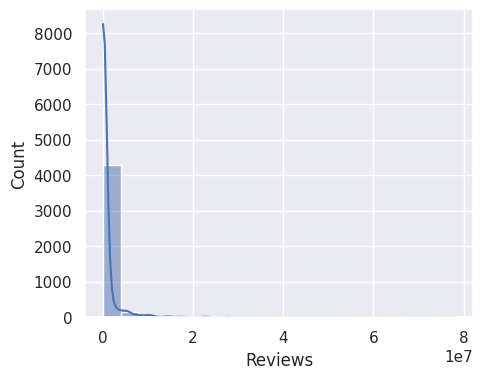

In [ ]:
sns.histplot(df,x='Reviews',kde=True,bins=20)
plt.show()

In [ ]:
df[df['Reviews'] > 2e7]

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
335,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56642847,12000000.0,1000000000,0.0,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,8,1
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,12000000.0,1000000000,0.0,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,8,3
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,12000000.0,1000000000,0.0,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,8,1
1654,Subway Surfers,GAME,4.5,27722264,76000000.0,1000000000,0.0,Arcade,0,0,1,0,0,8.627709e+07,4.355380,2.774011e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,12
1655,Candy Crush Saga,GAME,4.4,22426677,74000000.0,500000000,0.0,Casual,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,5
1660,Clash Royale,GAME,4.6,23133508,97000000.0,100000000,0.0,Strategy,0,0,1,0,0,3.401869e+07,4.369048,6.122046e+06,5.649276e+07,4.381076,2.566874e+06,2018,6,27
1670,Clash of Clans,GAME,4.6,44891723,98000000.0,100000000,0.0,Strategy,0,0,1,0,0,3.401869e+07,4.369048,6.122046e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,15
1700,Subway Surfers,GAME,4.5,27723193,76000000.0,1000000000,0.0,Arcade,0,0,1,0,0,8.627709e+07,4.355380,2.774011e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,12
1705,Candy Crush Saga,GAME,4.4,22428456,74000000.0,500000000,0.0,Casual,0,1,0,0,0,1.156919e+08,4.326087,4.944415e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,5
1721,Clash Royale,GAME,4.6,23134775,97000000.0,100000000,0.0,Strategy,0,0,1,0,0,3.401869e+07,4.369048,6.122046e+06,5.649276e+07,4.381076,2.566874e+06,2018,6,27


In [ ]:
df[df['App'].duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
285,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80804,16000000.0,5000000,0.0,Business,0,1,0,0,0,7.219806e+06,4.191304,1.046397e+05,7.219806e+06,4.191304,1.046397e+05,2018,2,26
293,OfficeSuite : Free Office + PDF Editor,BUSINESS,4.3,1002859,35000000.0,100000000,0.0,Business,0,1,0,0,0,7.219806e+06,4.191304,1.046397e+05,7.219806e+06,4.191304,1.046397e+05,2018,8,2
294,Slack,BUSINESS,4.4,51510,16000000.0,5000000,0.0,Business,0,1,0,0,0,7.219806e+06,4.191304,1.046397e+05,7.219806e+06,4.191304,1.046397e+05,2018,8,2
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,12000000.0,1000000000,0.0,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,8,1
383,imo free video calls and chat,COMMUNICATION,4.3,4785988,11000000.0,500000000,0.0,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,6,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4949,"CM Browser - Ad Blocker , Fast Download , Privacy",COMMUNICATION,4.6,2265084,6100000.0,50000000,0.0,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,7,31
4979,Google Ads,BUSINESS,4.3,29331,20000000.0,5000000,0.0,Business,0,1,0,0,0,7.219806e+06,4.191304,1.046397e+05,7.219806e+06,4.191304,1.046397e+05,2018,7,30
4987,Mobi Calculator free & AD free!,TOOLS,4.6,77302,5600000.0,5000000,0.0,Tools,0,1,0,0,0,3.501525e+07,4.102346,6.545866e+05,3.492085e+07,4.103846,6.534083e+05,2018,1,9
4989,Flipp - Weekly Shopping,SHOPPING,4.6,85782,18000000.0,10000000,0.0,Shopping,0,1,0,0,0,1.890863e+07,4.297656,7.121591e+05,1.890863e+07,4.297656,7.121591e+05,2018,7,30


In [ ]:
df[df.duplicated('App', keep=False)].sort_values('App')

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
1675,8 Ball Pool,GAME,4.5,14198297,52000000.0,100000000,0.0,Sports,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,31
1703,8 Ball Pool,GAME,4.5,14198602,52000000.0,100000000,0.0,Sports,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,31
1755,8 Ball Pool,GAME,4.5,14200344,52000000.0,100000000,0.0,Sports,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,31
1844,8 Ball Pool,GAME,4.5,14200550,52000000.0,100000000,0.0,Sports,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,31
1871,8 Ball Pool,GAME,4.5,14201891,52000000.0,100000000,0.0,Sports,0,1,0,0,0,1.383234e+07,4.285105,1.149433e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,stranger chat - anonymous chat,DATING,3.5,13204,6100000.0,1000000,0.0,Dating,0,0,0,1,0,8.893909e+05,3.980667,2.203548e+04,8.893909e+05,3.980667,2.203548e+04,2018,7,7
2590,textPlus: Free Text & Calls,SOCIAL,4.1,382120,28000000.0,10000000,0.0,Social,0,1,0,0,0,8.970473e+07,4.271642,3.834209e+06,8.970473e+07,4.271642,3.834209e+06,2018,7,26
2637,textPlus: Free Text & Calls,SOCIAL,4.1,382121,28000000.0,10000000,0.0,Social,0,1,0,0,0,8.970473e+07,4.271642,3.834209e+06,8.970473e+07,4.271642,3.834209e+06,2018,7,26
3055,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4,133833,34000000.0,10000000,0.0,Sports,0,0,1,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06,4.259350,3.293917e+05,2018,7,25


In [ ]:
df = df.sort_values('Reviews', ascending=False)
df.drop_duplicates(subset='App', keep='first',inplace=True)

In [ ]:
df[df.duplicated('App', keep=False)].sort_values('App')

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day


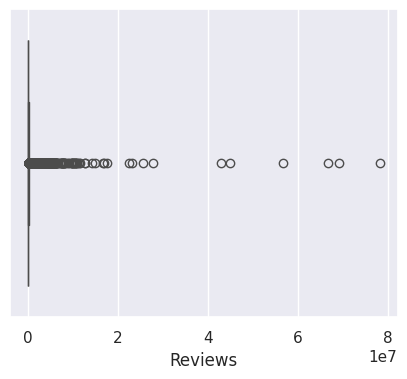

In [ ]:
sns.boxplot(df,x='Reviews')
plt.show()

In [ ]:
df[df['Reviews'] > 4e7]

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
2544,Facebook,SOCIAL,4.1,78158306,15000000.0,1000000000,0.0,Social,0,0,0,0,1,8.970473e+07,4.271642,3.834209e+06,8.970473e+07,4.271642,3.834209e+06,2018,8,3
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,12000000.0,1000000000,0.0,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,8,3
2604,Instagram,SOCIAL,4.5,66577446,15000000.0,1000000000,0.0,Social,0,0,0,0,1,8.970473e+07,4.271642,3.834209e+06,8.970473e+07,4.271642,3.834209e+06,2018,7,31
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,12000000.0,1000000000,0.0,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,8,1
1879,Clash of Clans,GAME,4.6,44893888,98000000.0,100000000,0.0,Strategy,0,0,1,0,0,3.401869e+07,4.369048,6.122046e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,15
4005,Clean Master- Space Cleaner & Antivirus,TOOLS,4.7,42916526,5600000.0,500000000,0.0,Tools,0,1,0,0,0,3.501525e+07,4.102346,6.545866e+05,3.492085e+07,4.103846,6.534083e+05,2018,8,3


The extreme number of reviews is justified as per the apps which are very popular globally.

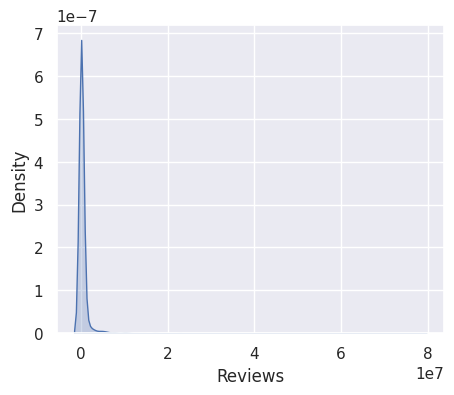

In [ ]:
sns.kdeplot(df,x='Reviews',fill=True)
plt.show()

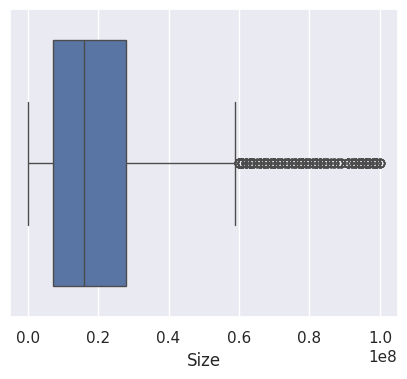

In [ ]:
sns.boxplot(df,x='Size')
plt.show()

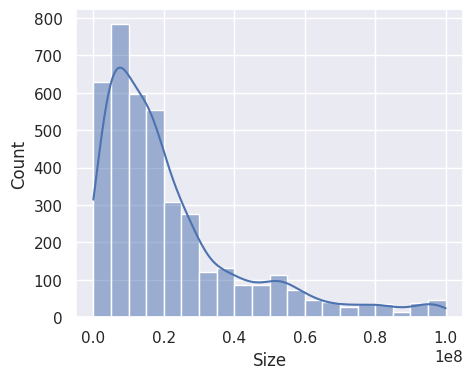

In [ ]:
sns.histplot(df,x='Size',kde=True,bins=20)
plt.show()

Some kinds of apps tend to have higher size like Games

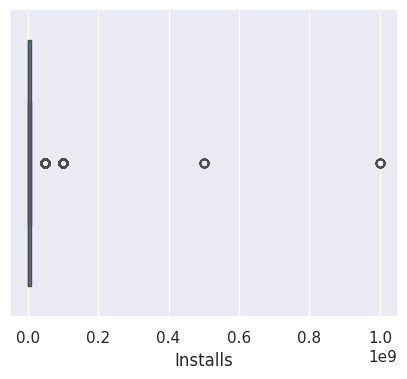

In [ ]:
sns.boxplot(df,x='Installs')
plt.show()

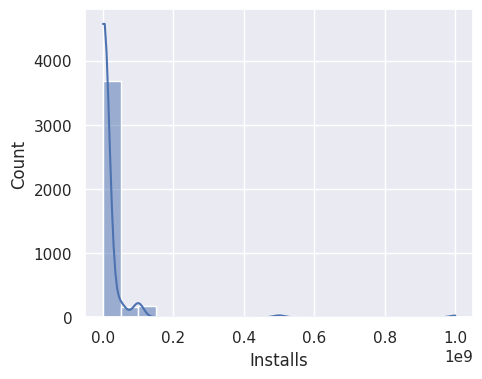

In [ ]:
sns.histplot(df,x='Installs',kde=True,bins=20)
plt.show()

In [ ]:
df

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
2544,Facebook,SOCIAL,4.100000,78158306,15000000.0,1000000000,0.00,Social,0,0,0,0,1,8.970473e+07,4.271642,3.834209e+06,8.970473e+07,4.271642,3.834209e+06,2018,8,3
336,WhatsApp Messenger,COMMUNICATION,4.400000,69119316,12000000.0,1000000000,0.00,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,8,3
2604,Instagram,SOCIAL,4.500000,66577446,15000000.0,1000000000,0.00,Social,0,0,0,0,1,8.970473e+07,4.271642,3.834209e+06,8.970473e+07,4.271642,3.834209e+06,2018,7,31
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.000000,56646578,12000000.0,1000000000,0.00,Communication,0,1,0,0,0,1.325120e+08,4.227528,3.237087e+06,1.325120e+08,4.227528,3.237087e+06,2018,8,1
1879,Clash of Clans,GAME,4.600000,44893888,98000000.0,100000000,0.00,Strategy,0,0,1,0,0,3.401869e+07,4.369048,6.122046e+06,5.649276e+07,4.381076,2.566874e+06,2018,7,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,i miss you quotes and photos,DATING,3.980667,0,5000000.0,100,0.00,Dating,0,1,0,0,0,8.893909e+05,3.980667,2.203548e+04,8.893909e+05,3.980667,2.203548e+04,2018,7,22
4218,D+H Reaction Wall,GAME,4.381076,0,53000000.0,1,0.99,Arcade,0,1,0,0,0,8.627709e+07,4.355380,2.774011e+06,5.649276e+07,4.381076,2.566874e+06,2016,7,24
4177,G-NetReport Pro,TOOLS,4.103846,0,1600000.0,10,25.99,Tools,0,1,0,0,0,3.501525e+07,4.102346,6.545866e+05,3.492085e+07,4.103846,6.534083e+05,2018,6,14
4273,J. Polep Plus Mobile,PRODUCTIVITY,4.251744,0,44000000.0,100,0.00,Productivity,0,1,0,0,0,6.833561e+07,4.251744,5.384339e+05,6.833561e+07,4.251744,5.384339e+05,2018,3,26


In [ ]:
df.to_csv('google_play_store_cleaned.csv',index=False)

Now, discovering what makes an app popular

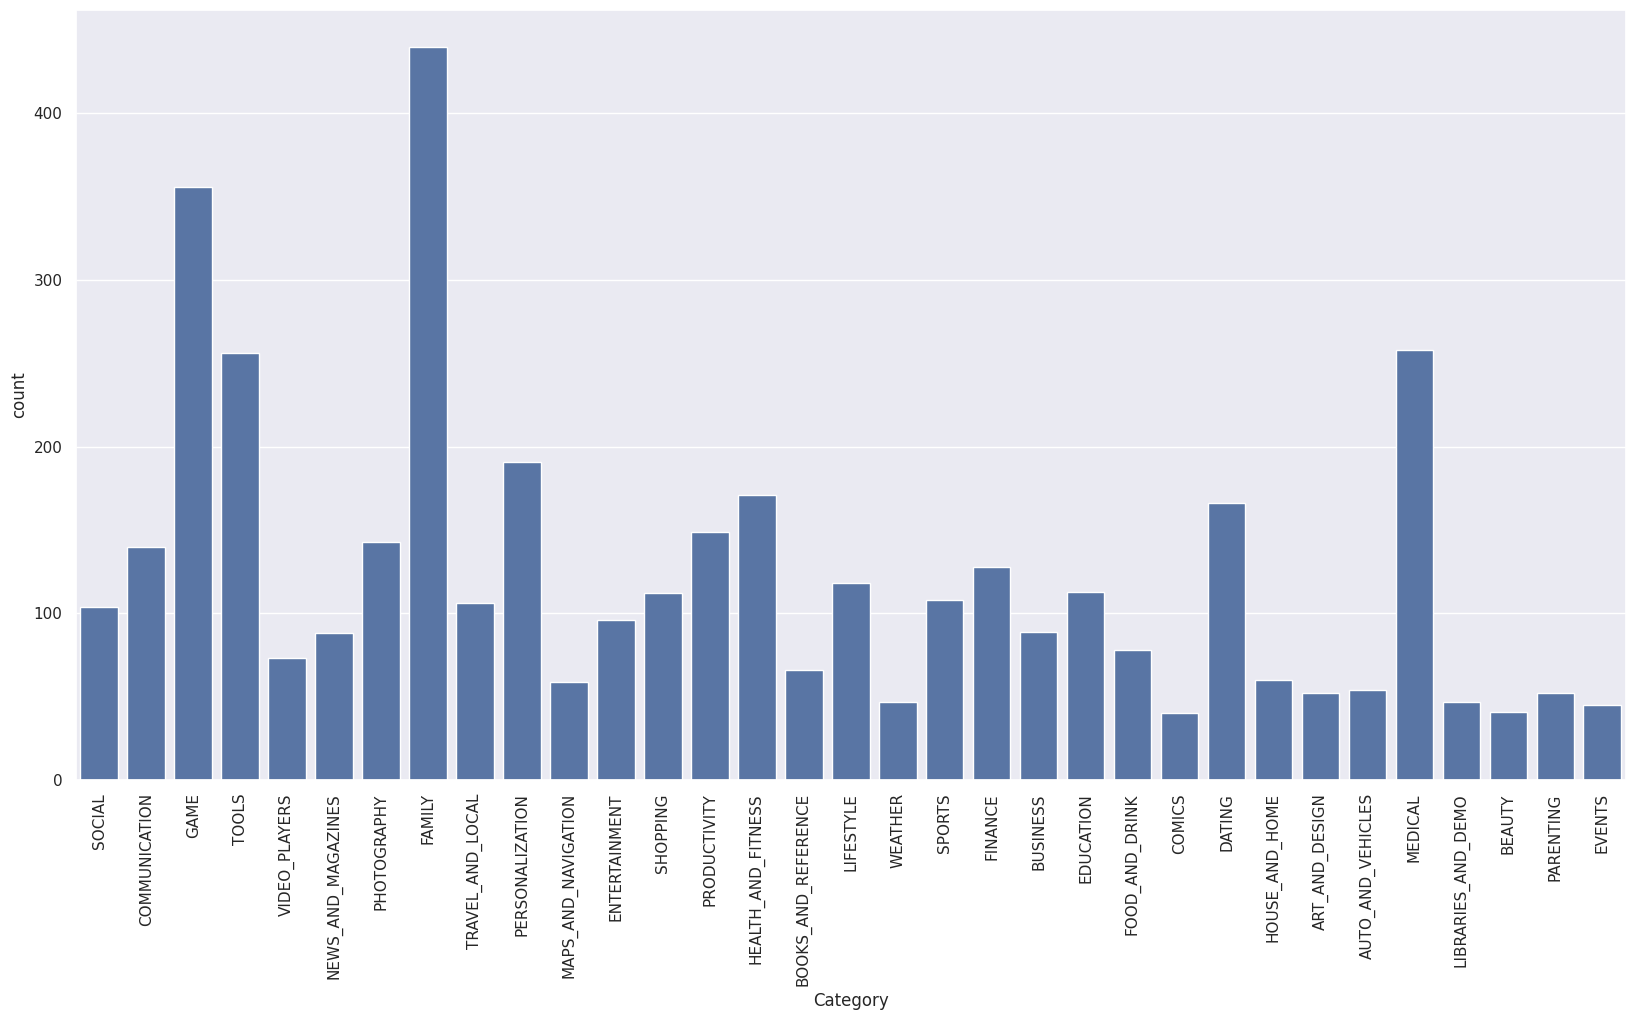

In [ ]:
sns.set(rc={'figure.figsize':(20,10)})
sns.countplot(df,x='Category')
plt.xticks(rotation=90)
plt.show()

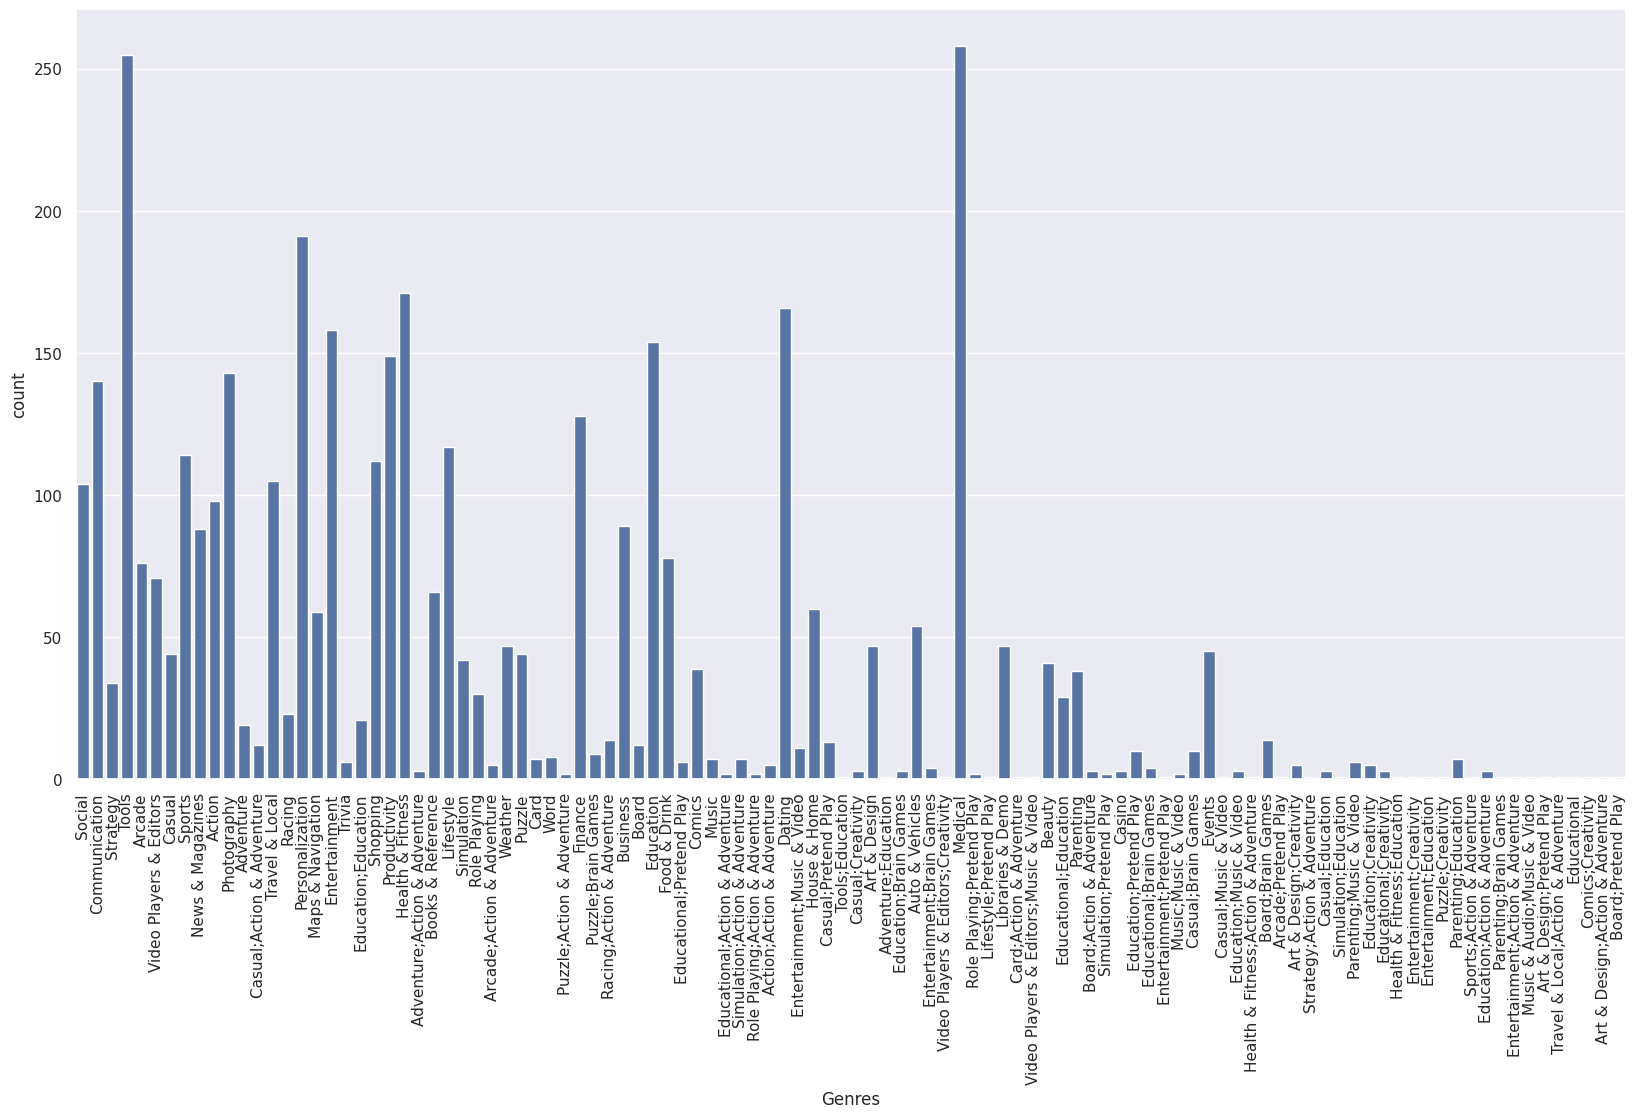

In [ ]:
sns.countplot(df,x='Genres')
plt.xticks(rotation=90)
plt.show()

Determining app popularity through number of installs

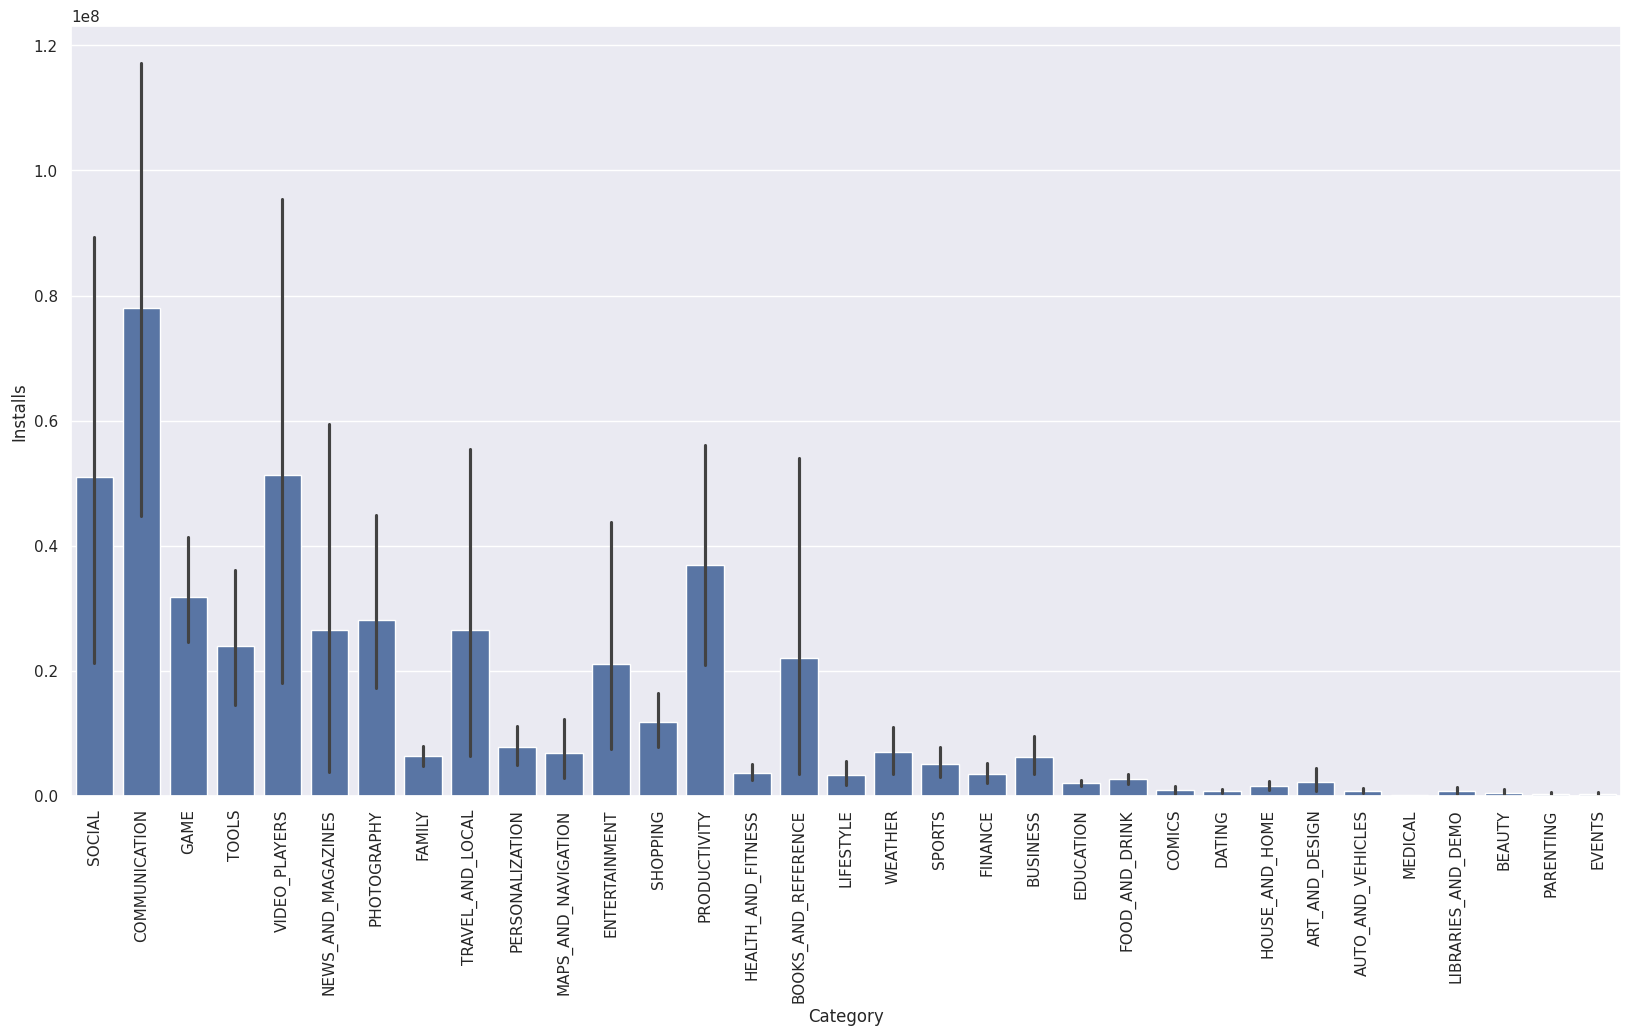

In [ ]:
sns.barplot(df,x='Category',y='Installs')
plt.xticks(rotation=90)
plt.show()

Communication, Social, Video Players, Productivity, Game, Photography, News and Magazines, Travel and Local, Tools, Books and Reference, Entertainment, Shopping

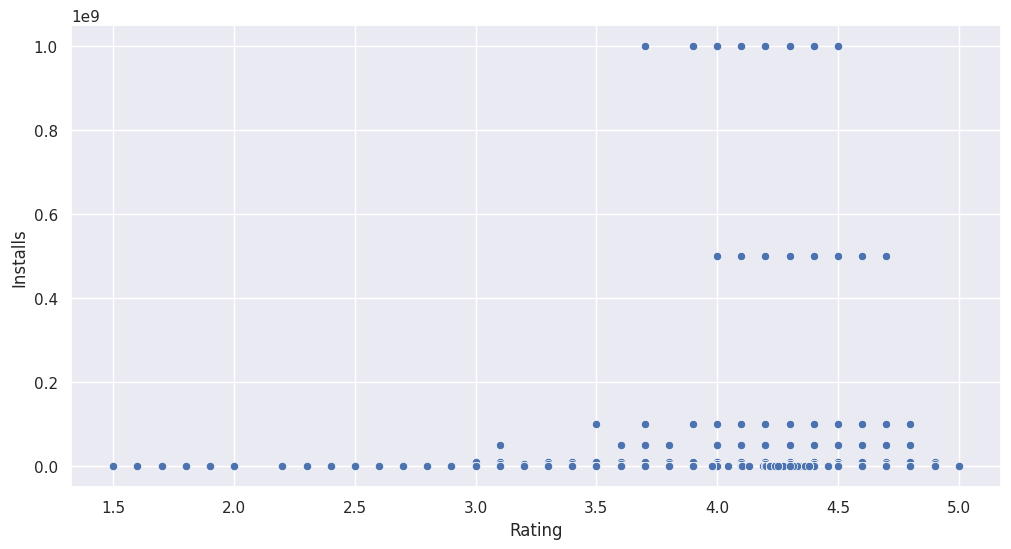

In [ ]:
sns.set(rc={'figure.figsize':(12,6)})
sns.scatterplot(df,x='Rating',y='Installs')
plt.show()

Installs increase as rating increases

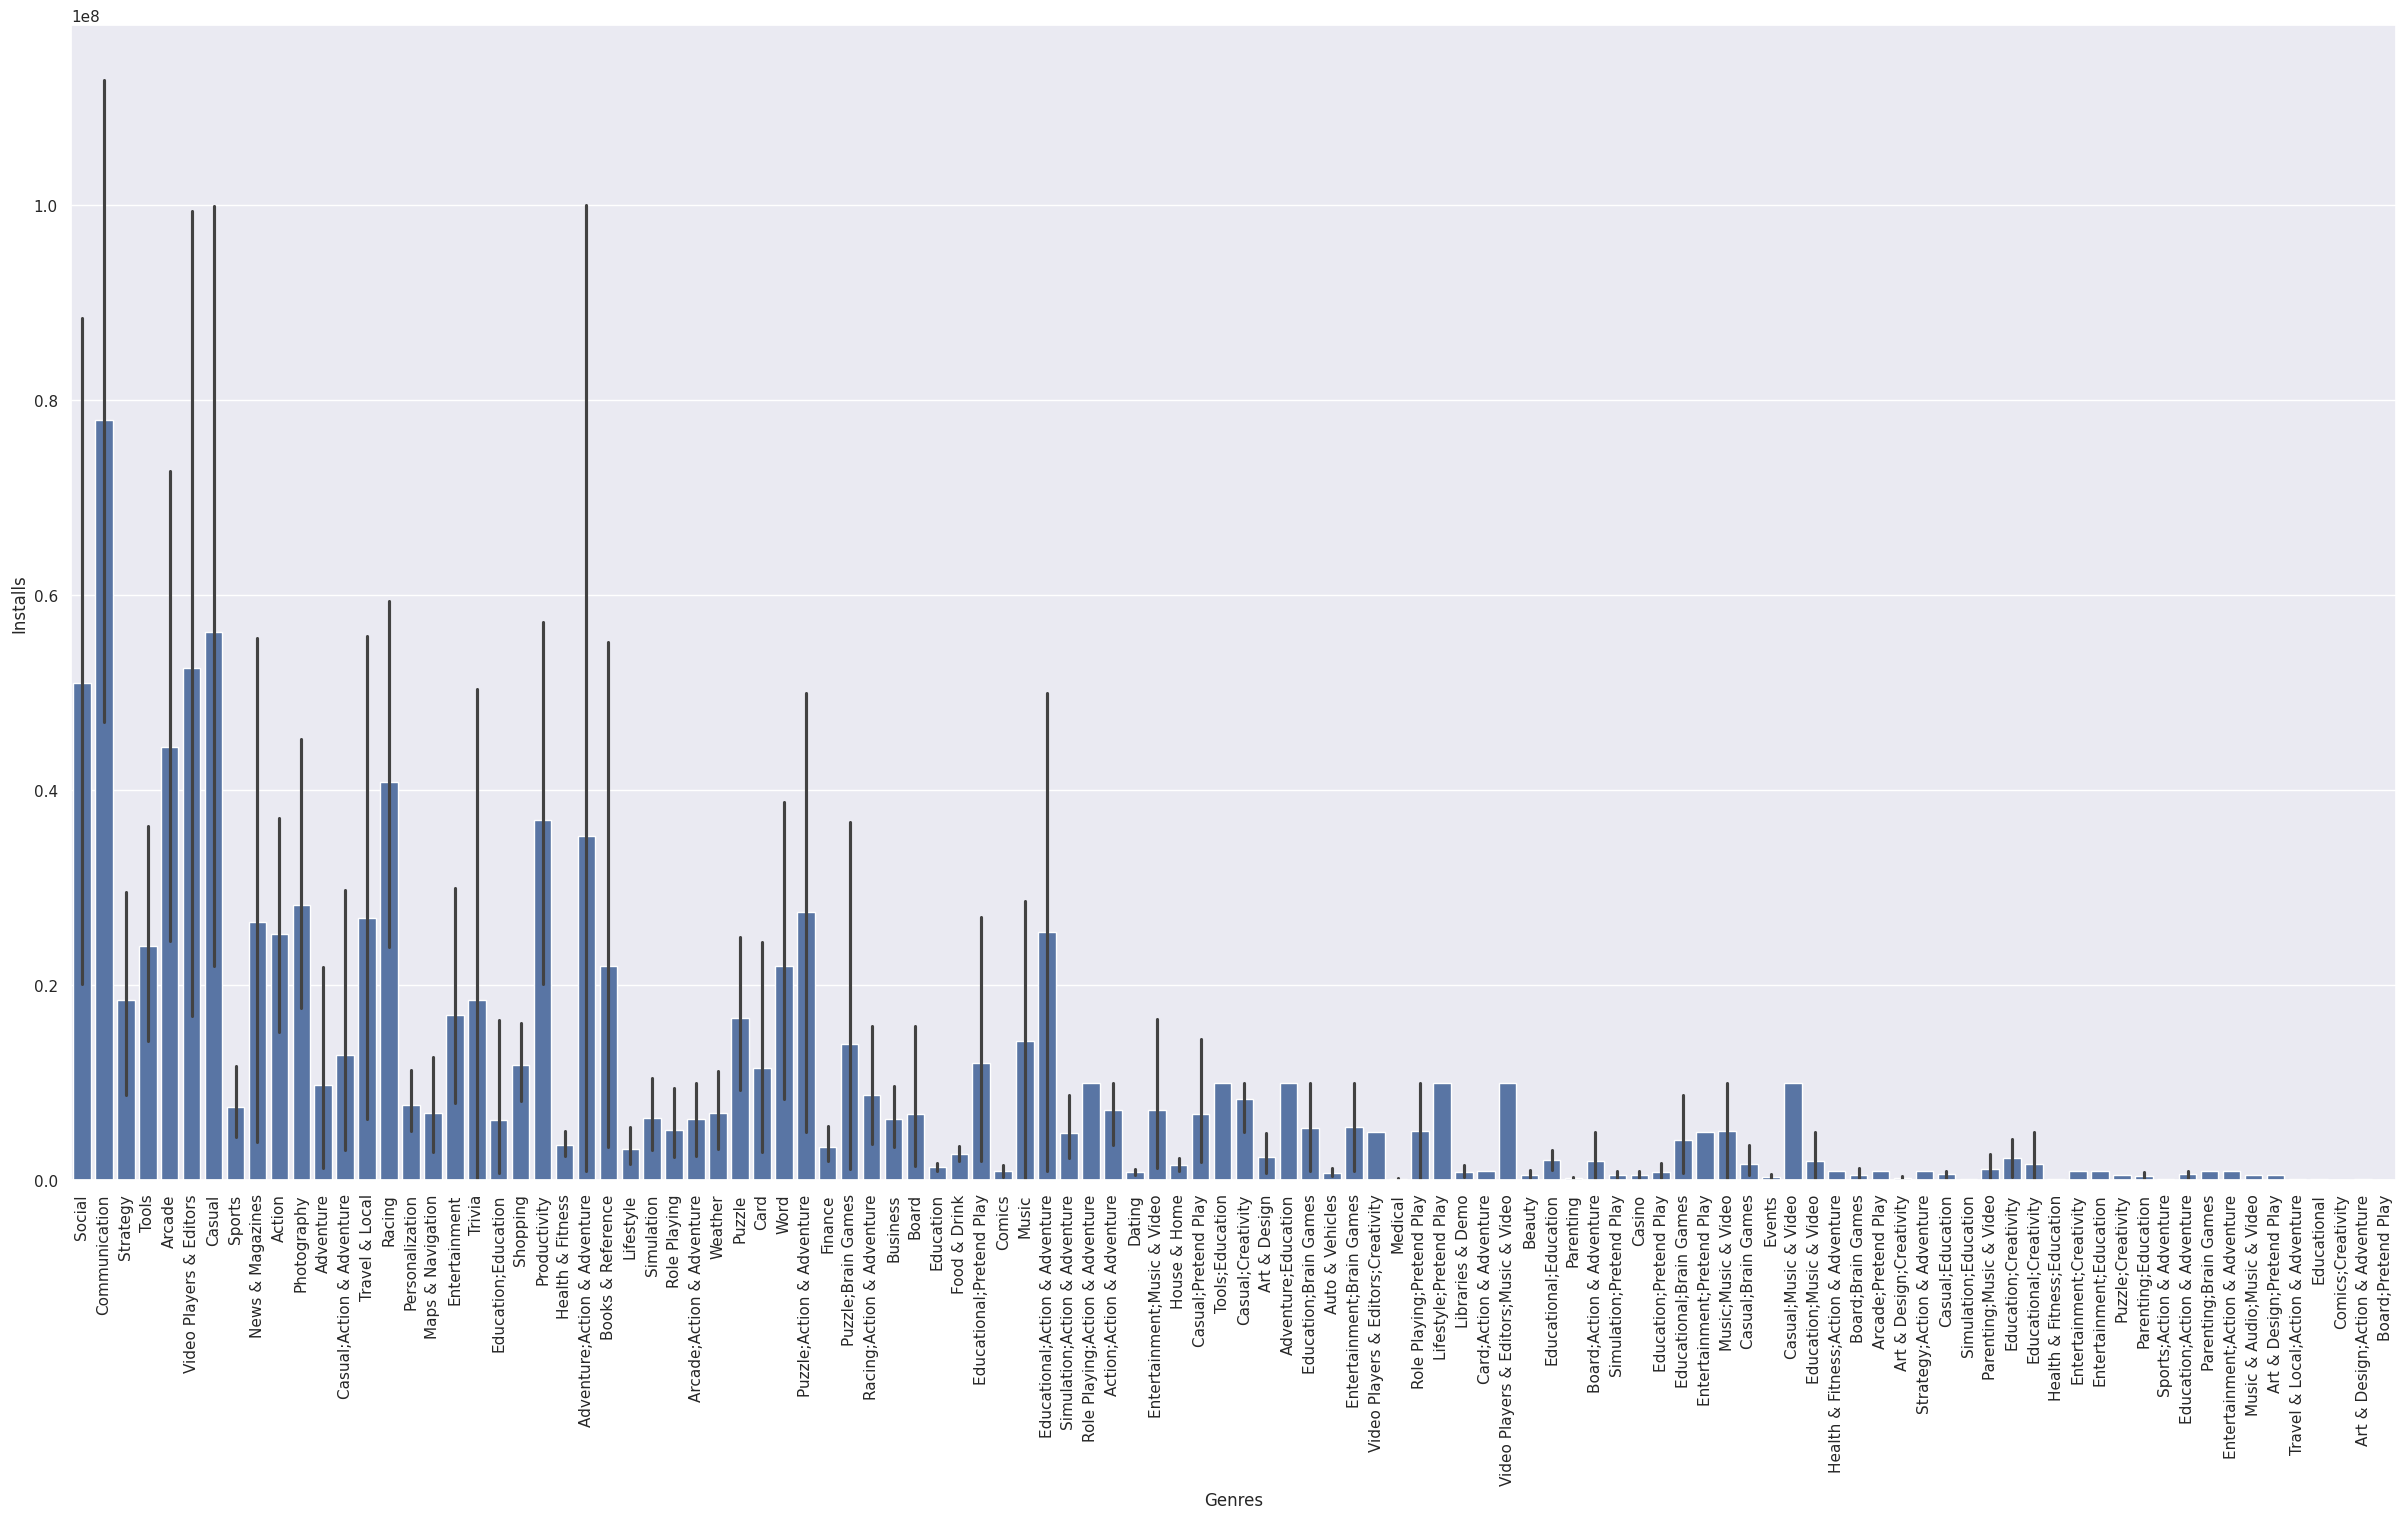

In [ ]:
sns.set(rc={'figure.figsize':(30,15)})
sns.barplot(df,x='Genres',y='Installs')
plt.xticks(rotation=90)
plt.show()

Communication, Casual, Video Players and Editors, Social, Arcade, Racing, Productivity, Adventure;Action and Adventure, Puzzle;Action and Adventure, Photography, News & Magazine, Travel and Local, Educational;Action and Adventure, Action, Books and Reference, Word, Trivia, Entertainment, Puzzle

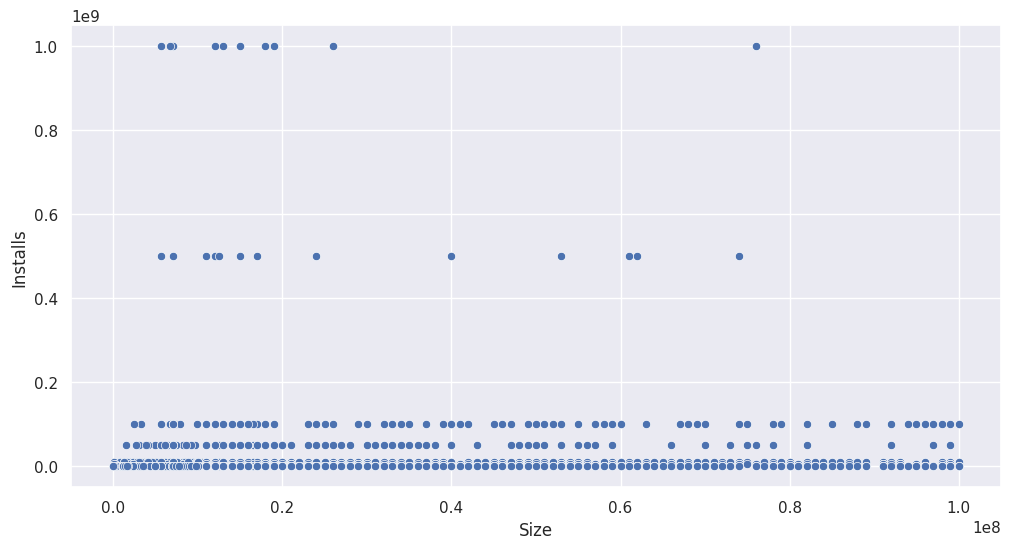

In [ ]:
sns.set(rc={'figure.figsize':(12,6)})
sns.scatterplot(df,x='Size',y='Installs')
plt.show()

Lower size apps, gets more installs therefore they are more popular

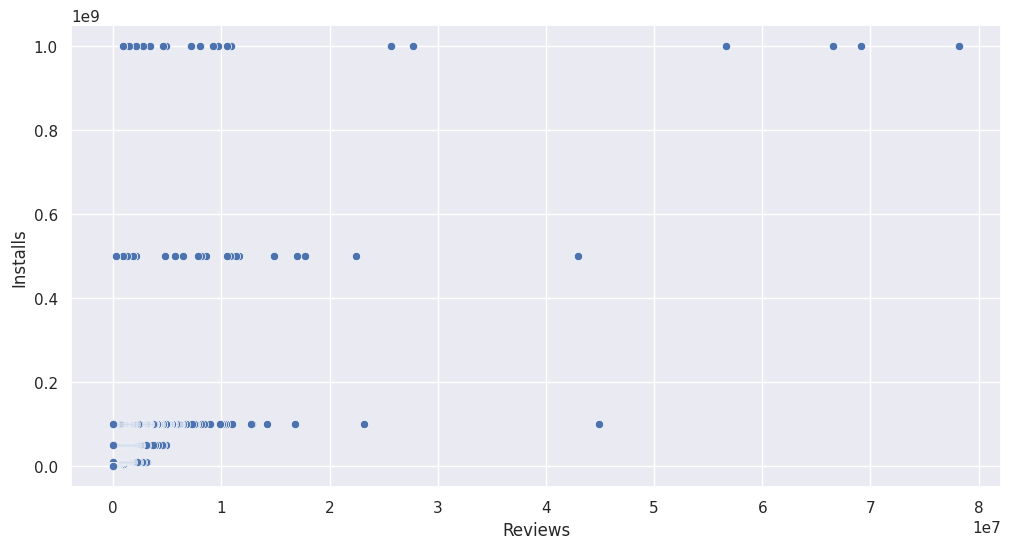

In [ ]:
sns.scatterplot(df,x='Reviews',y='Installs')
plt.show()

Higher reviews gets more installs

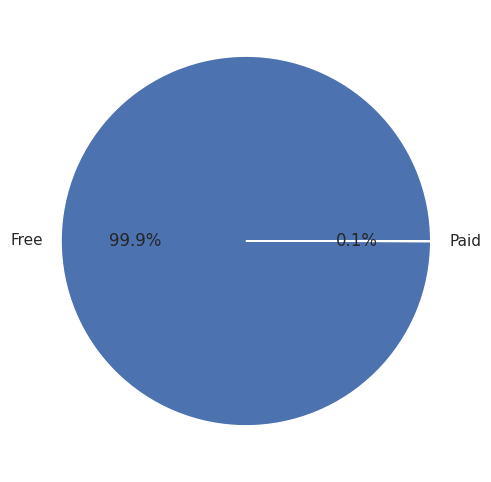

Total number of installs for free apps: 65422018294
Total number of installs for paid apps: 32845125


In [ ]:
installs_price_free = df[df['Price (in dollars)'] == 0.0]['Installs'].sum()
installs_price_paid = df[df['Price (in dollars)'] != 0.0]['Installs'].sum()
plt.pie([installs_price_free,installs_price_paid],labels=['Free','Paid'],autopct='%1.1f%%')
plt.show()
print("Total number of installs for free apps:",installs_price_free)
print("Total number of installs for paid apps:",installs_price_paid)

99.9% installs are of free app and just 0.1% is of paid apps. Therefore, free apps are more popular than paid

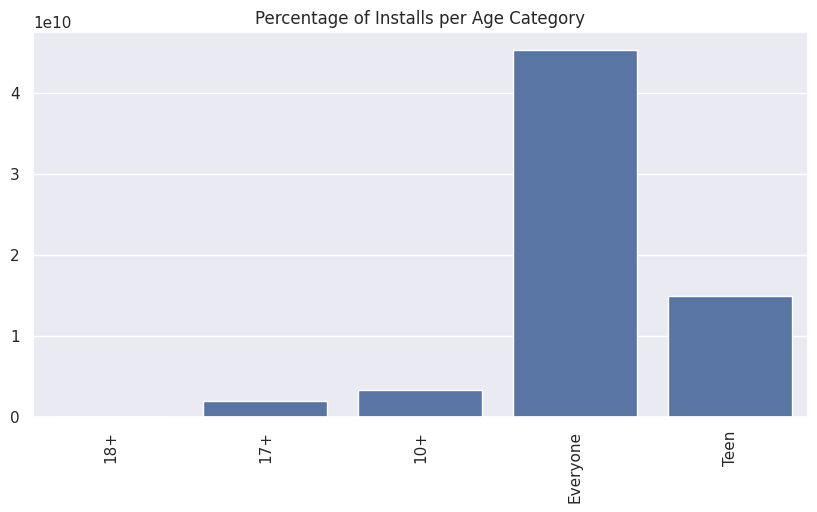

AGE CATEGORY : INSTALLS
18+: 1500000
17+: 1968550101
10+: 3327453110
Everyone: 45257368098
Teen: 14899992110


In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
content_18 = df[df['Content_Rating_18+'] == 1]['Installs'].sum()
content_17 = df[df['Content_Rating_17+'] == 1]['Installs'].sum()
content_10 = df[df['Content_Rating_10+'] == 1]['Installs'].sum()
content_everyone = df[df['Content Rating_Everyone'] == 1]['Installs'].sum()
content_teen = df[df['Content Rating_Teen'] == 1]['Installs'].sum()
plt.title("Percentage of Installs per Age Category")
sns.barplot(x=['18+','17+','10+','Everyone','Teen'],y=[content_18,content_17,content_10,content_everyone,content_teen])
plt.xticks(rotation=90)
plt.show()
print("AGE CATEGORY : INSTALLS")
print("18+:",content_18)
print("17+:",content_17)
print("10+:",content_10)
print("Everyone:",content_everyone)
print("Teen:",content_teen)

In [ ]:
df[df['Content_Rating_18+'] == 1]

,App,Category,Rating,Reviews,Size,Installs,Price (in dollars),Genres,Content_Rating_18+,Content Rating_Everyone,Content_Rating_10+,Content_Rating_17+,Content Rating_Teen,Genres_Installs_encoded,Genres_Ratings_encoded,Genres_Reviews_encoded,Category_Installs_encoded,Category_Rating_encoded,Category_Reviews_encoded,Last_Updated_Year,Last_Updated_Month,Last_Updated_Day
3043,DraftKings - Daily Fantasy Sports,SPORTS,4.5,50017,41000000.0,1000000,0.0,Sports,1,0,0,0,0,1.383234e+07,4.285105,1.149433e+06,7.088961e+06,4.25935,329391.709677,2018,7,24
298,Manga Master - Best manga & comic reader,COMICS,4.6,24005,4900000.0,500000,0.0,Comics,1,0,0,0,0,1.163525e+06,4.290062,8.059082e+04,1.136366e+06,4.30250,78637.780488,2018,7,4


Highest Number of Installs is for app for all age categories that is 'Everyone'. Therefore, apps for everyone are more popular

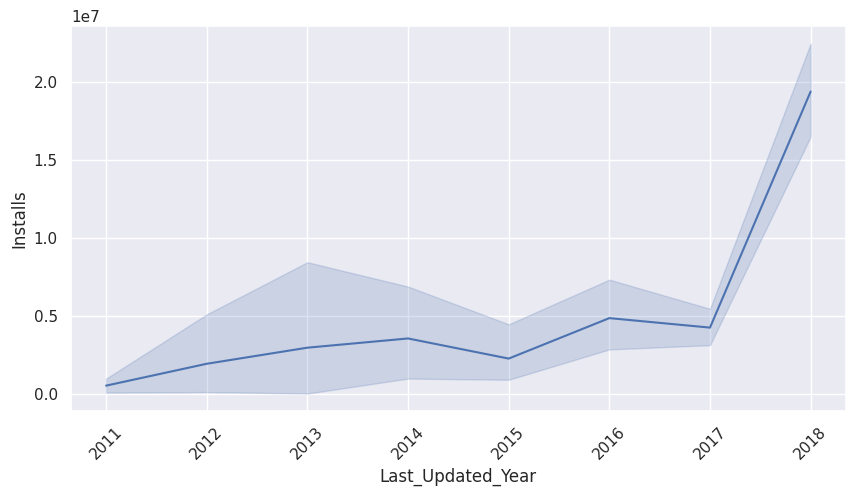

In [ ]:
sns.set(rc={'figure.figsize':(10,5)})
sns.lineplot(df,y='Installs',x='Last_Updated_Year')
plt.xticks(rotation=45)
plt.show()

Apps are installed more which are updated recently, that is they undergo frequent updates and are active. Such apps are popular.

Now analyzing popularity through ratings

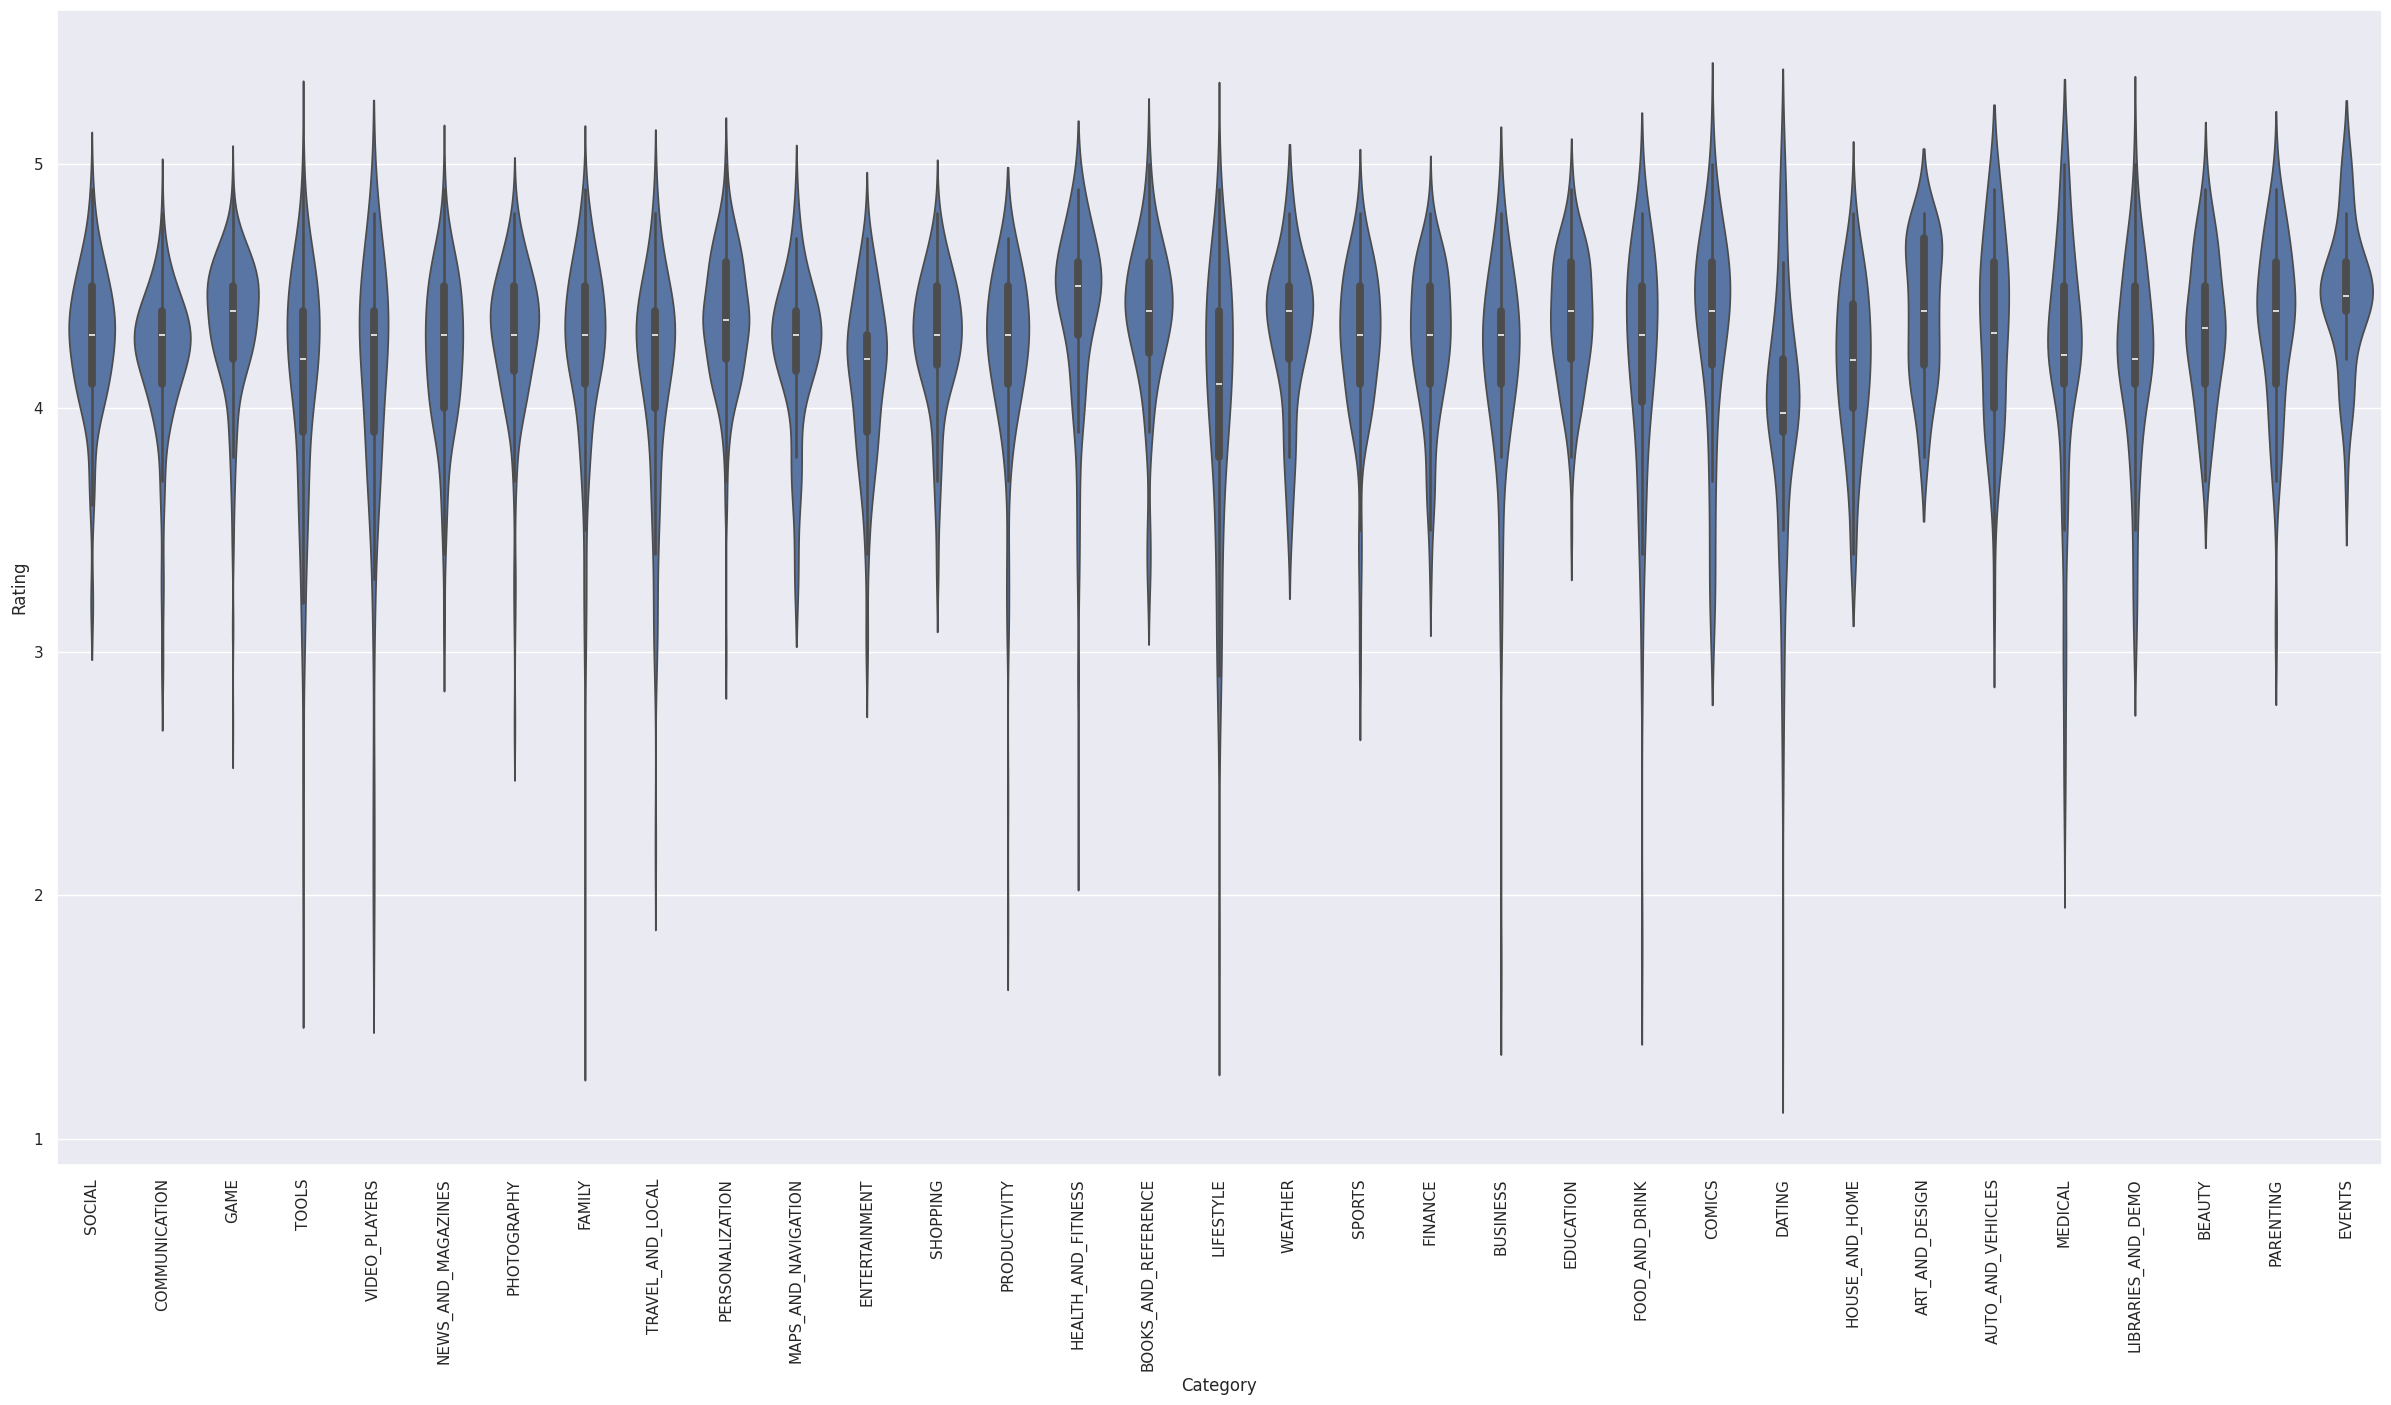

In [ ]:
sns.set(rc={'figure.figsize':(30,15)})
sns.violinplot(df,x='Category',y='Rating')
plt.xticks(rotation=90)
plt.show()

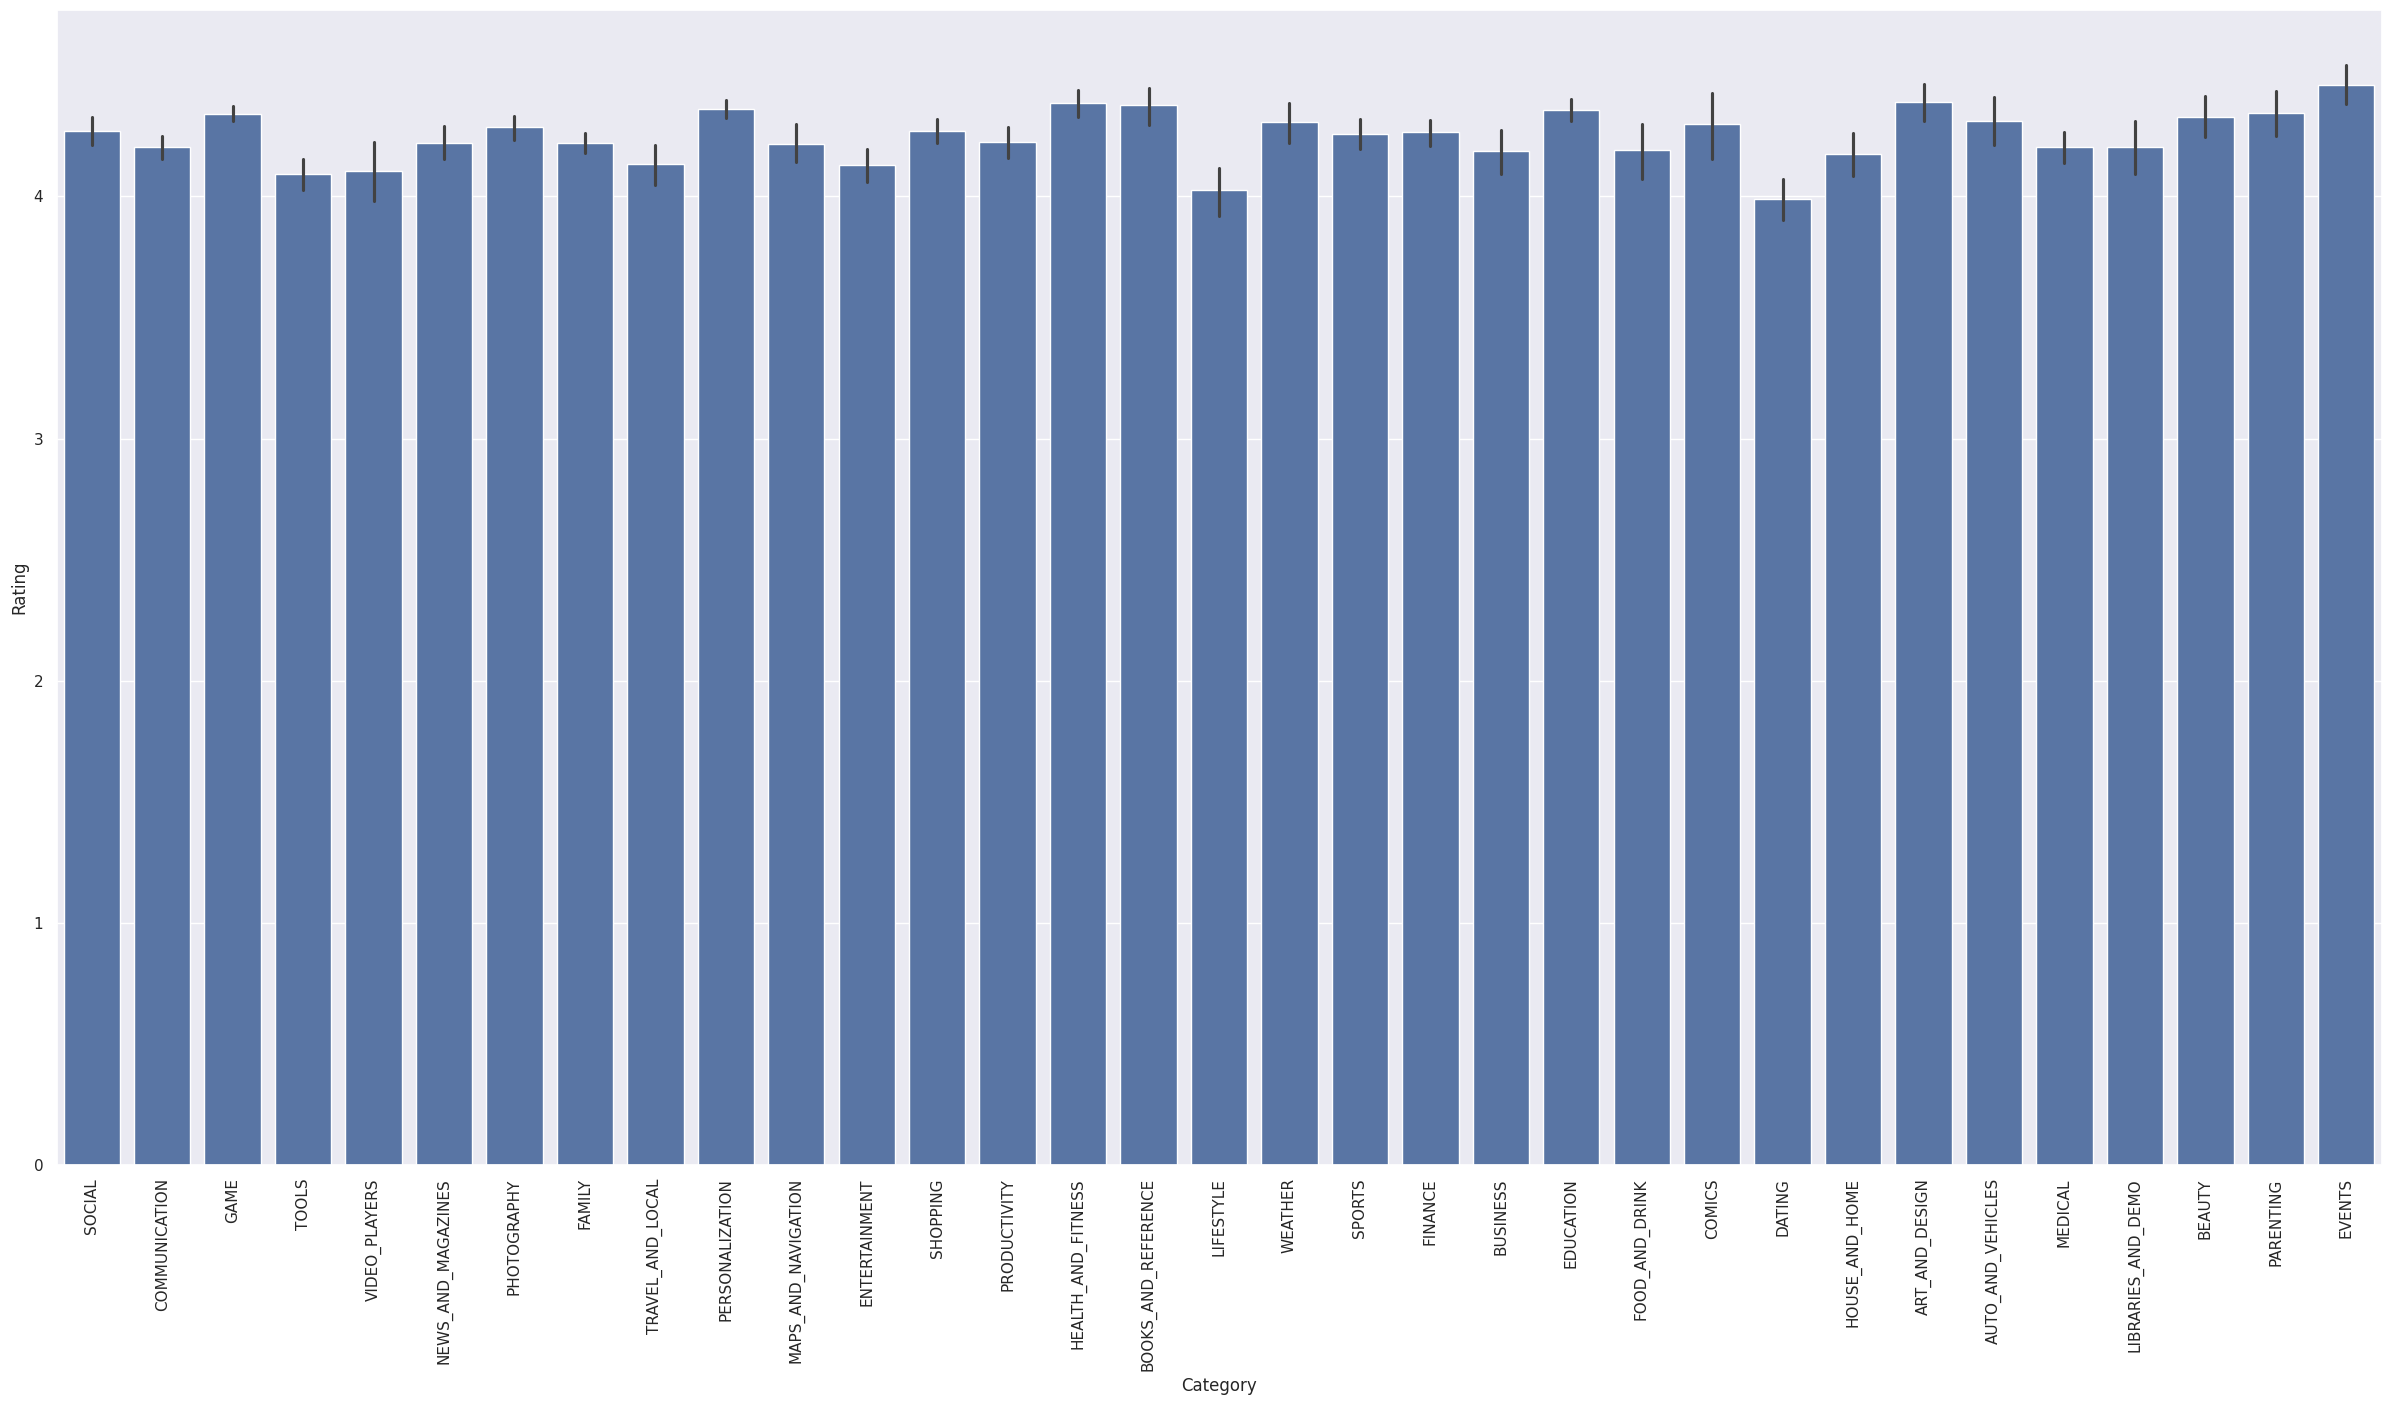

In [ ]:
sns.barplot(df,x='Category',y='Rating')
plt.xticks(rotation=90)
plt.show()

In [ ]:
print("----TOP 10 APP CATEGORIES AS PER RATINGS----")
top_10_category_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)[:20]
top_10_category_rating

----TOP 10 APP CATEGORIES AS PER RATINGS----


,Rating
Category,
EVENTS,4.458824
ART_AND_DESIGN,4.388462
HEALTH_AND_FITNESS,4.386550
BOOKS_AND_REFERENCE,4.376354
PERSONALIZATION,4.359555
EDUCATION,4.358194
PARENTING,4.345238
GAME,4.342150
BEAUTY,4.328571


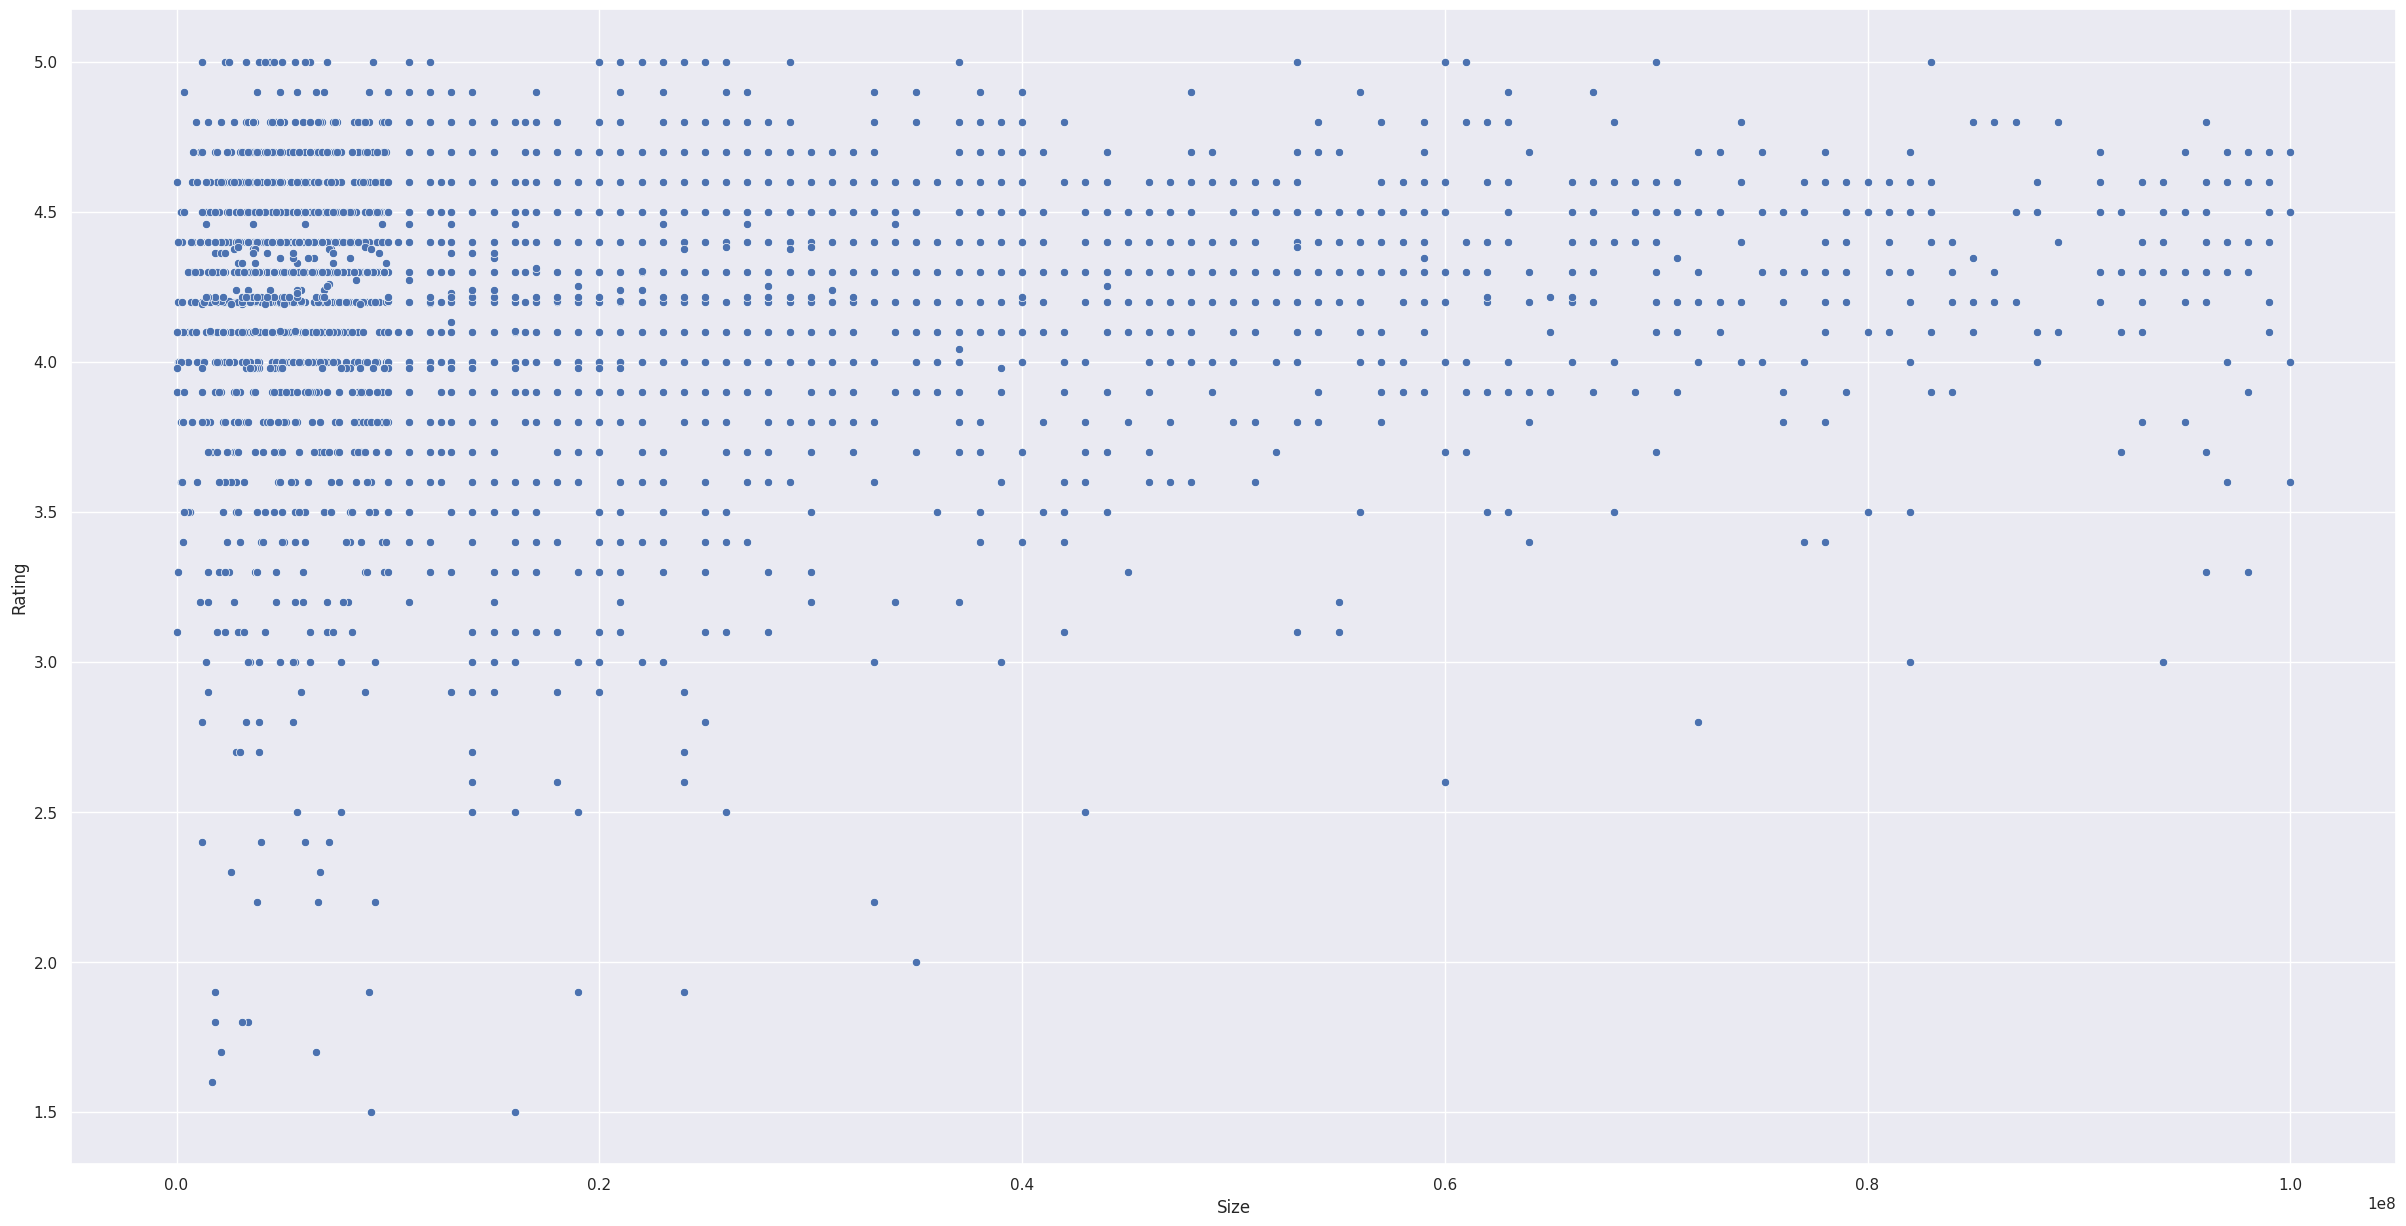

In [ ]:
sns.scatterplot(df,x='Size',y='Rating')
plt.show()

Higher rating density is higher for smaller apps

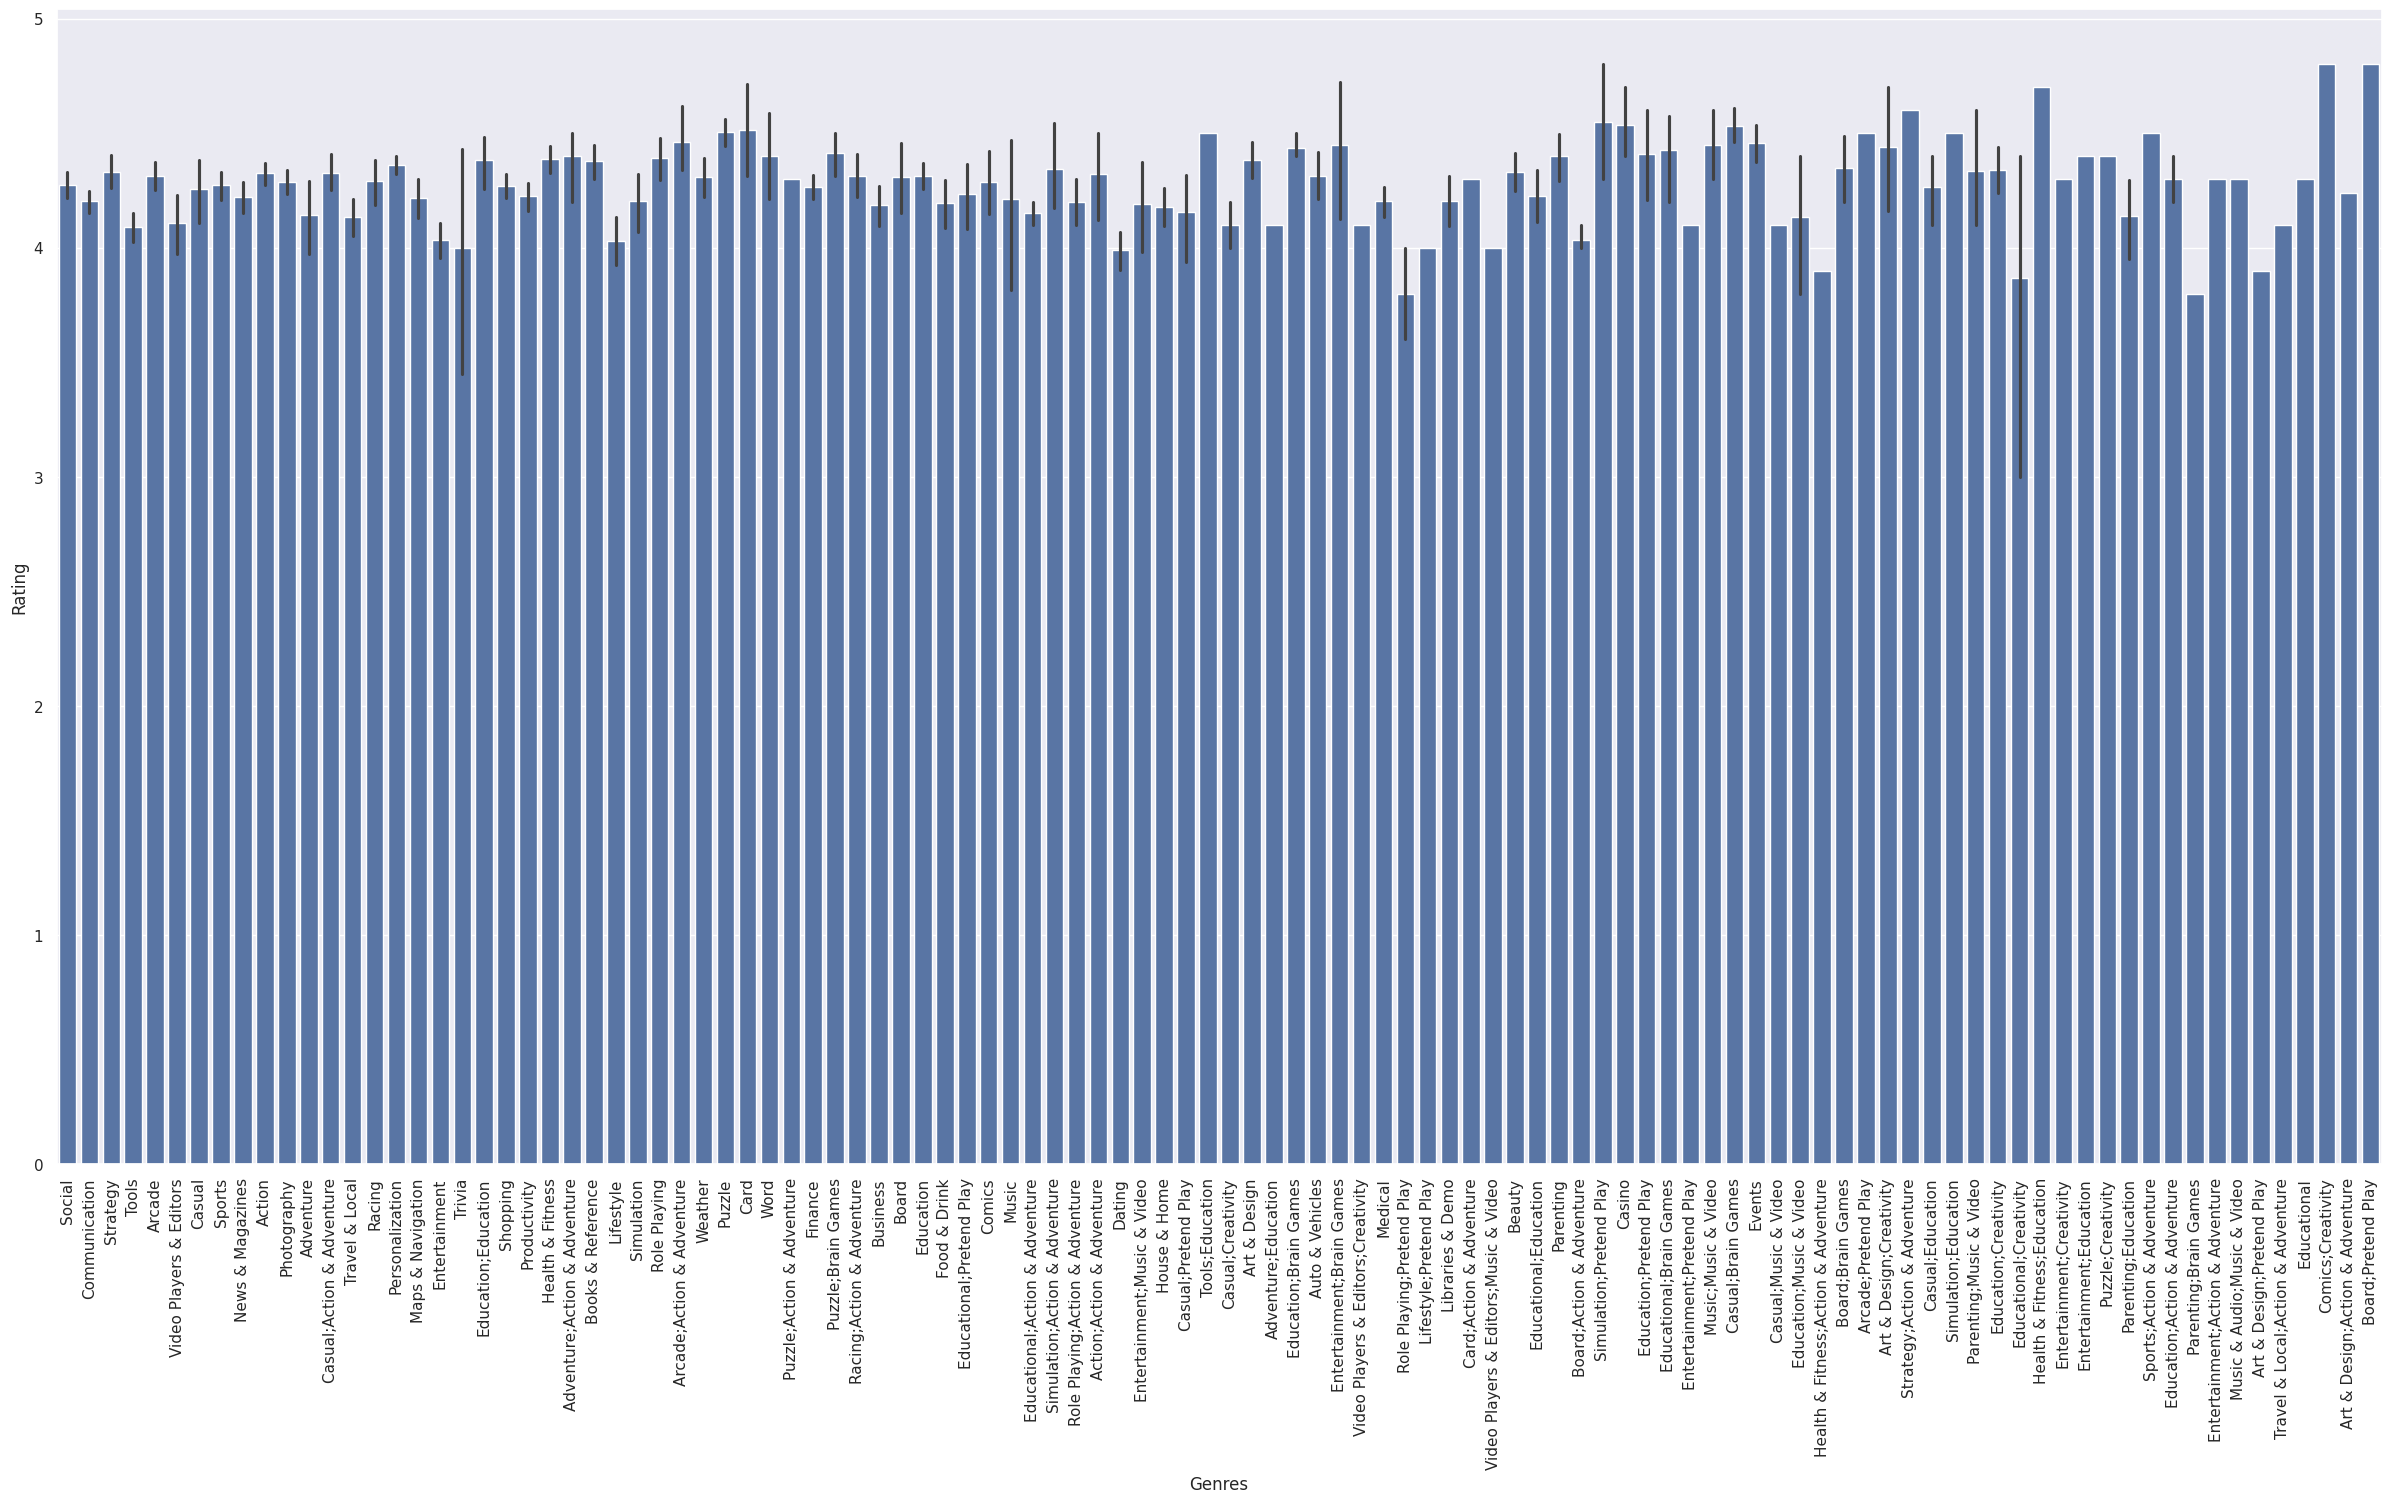

In [ ]:
sns.barplot(df,x='Genres',y='Rating')
plt.xticks(rotation=90)
plt.show()

In [ ]:
top_10_genres_rating = df.groupby('Genres')['Rating'].mean().sort_values(ascending=False)[:10]
top_10_genres_rating

,Rating
Genres,
Comics;Creativity,4.800000
Board;Pretend Play,4.800000
Health & Fitness;Education,4.700000
Strategy;Action & Adventure,4.600000
Simulation;Pretend Play,4.550000
Casino,4.533333
Casual;Brain Games,4.530000
Card,4.514286
Puzzle,4.506818


In [ ]:
rating_free = df[df['Price (in dollars)'] == 0.0]['Rating'].mean()
rating_paid = df[df['Price (in dollars)'] != 0.0]['Rating'].mean()

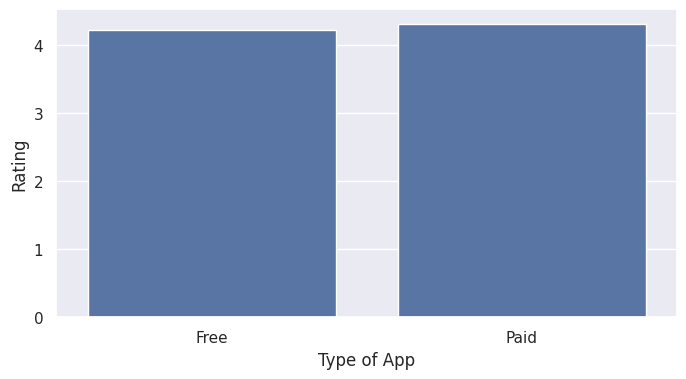

Average rating of free apps: 4.230131831934996
Average rating of paid apps: 4.3173953177228


In [ ]:
sns.set(rc={'figure.figsize':(8,4)})
sns.barplot(x=['Free','Paid'],y=[rating_free,rating_paid])
plt.xlabel('Type of App')
plt.ylabel('Rating')
plt.show()
print("Average rating of free apps:",rating_free)
print("Average rating of paid apps:",rating_paid)

There is a very slight difference in rating between free and paid apps. So price is not a strong determinant for rating.

In [ ]:
rating_content_18 = df[df['Content_Rating_18+'] == 1]['Rating'].mean()
rating_content_17 = df[df['Content_Rating_17+'] == 1]['Rating'].mean()
rating_content_10 = df[df['Content_Rating_10+'] == 1]['Rating'].mean()
rating_everyone = df[df['Content Rating_Everyone'] == 1]['Rating'].mean()
rating_teen = df[df['Content Rating_Teen'] == 1]['Rating'].mean()

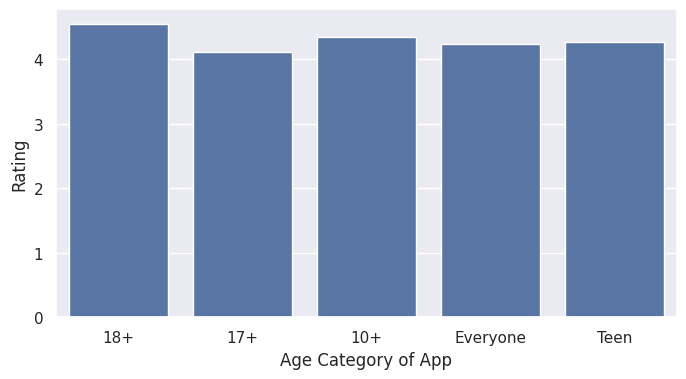

AGE CATEGORY : AVERAGE RATING
18+: 4.55
17+: 4.109364106205862
10+: 4.34259328582404
Everyone: 4.237796366945096
Teen: 4.265819472292068


In [ ]:
sns.barplot(x=['18+','17+','10+','Everyone','Teen'],y=[rating_content_18,rating_content_17,rating_content_10,rating_everyone,rating_teen])
plt.xlabel('Age Category of App')
plt.ylabel('Rating')
plt.show()
print('AGE CATEGORY : AVERAGE RATING')
print("18+:",rating_content_18)
print("17+:",rating_content_17)
print("10+:",rating_content_10)
print("Everyone:",rating_everyone)
print("Teen:",rating_teen)

18+ apps tend to have a higher rating but the difference with other categories is very little. Hence, its not a strong factor.

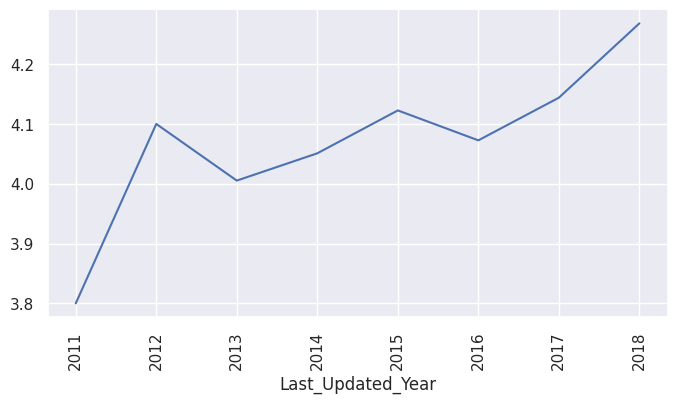

YEAR : AVERAGE RATING
2011 : 3.8
2012 : 4.1000000000000005
2013 : 4.005263157894737
2014 : 4.050909090909091
2015 : 4.1226082500241
2016 : 4.072564900564386
2017 : 4.143883018972236
2018 : 4.268184665408355


In [ ]:
rating_last_updated_year = df.groupby('Last_Updated_Year')['Rating'].mean()
sns.lineplot(x=rating_last_updated_year.index,y=rating_last_updated_year.values)
plt.xticks(rotation=90)
plt.show()
print('YEAR : AVERAGE RATING')
for i in range(len(rating_last_updated_year.values)):
  print(rating_last_updated_year.index[i],":",rating_last_updated_year.values[i])

Apps that are frequently updated tend to have higher rating.

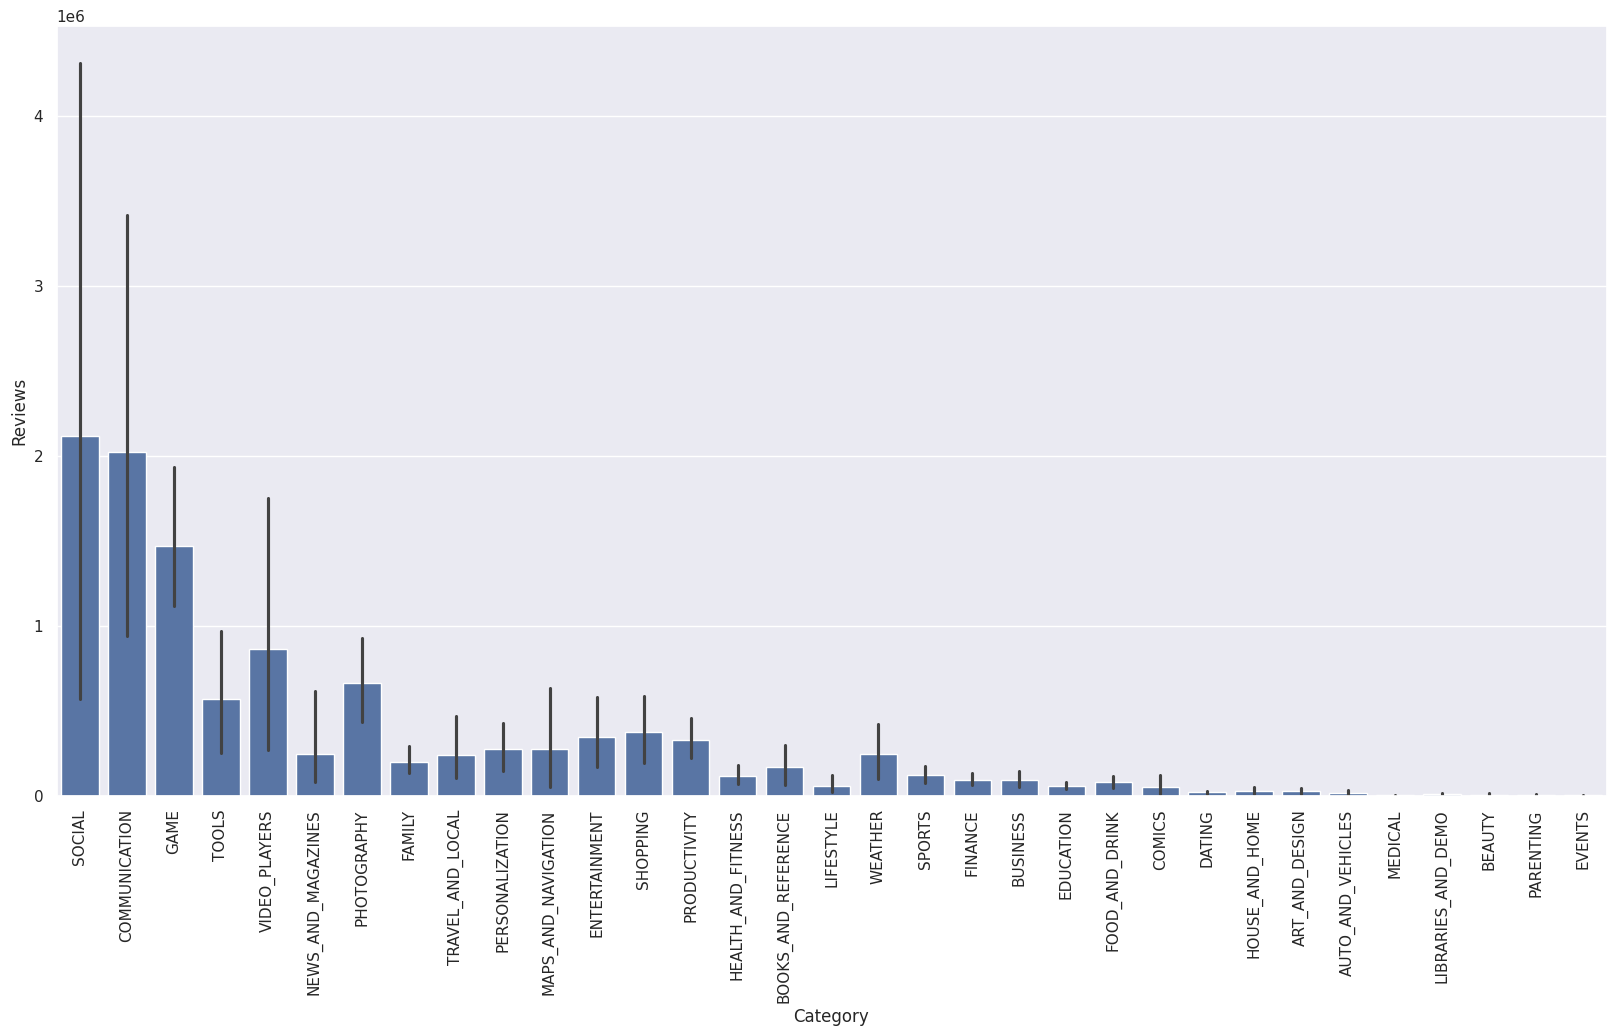

In [ ]:
sns.set(rc={'figure.figsize':(20,10)})
sns.barplot(df,x='Category',y='Reviews')
plt.xticks(rotation=90)
plt.show()

Social,Communication,Game,Video Players,Photography,Tools

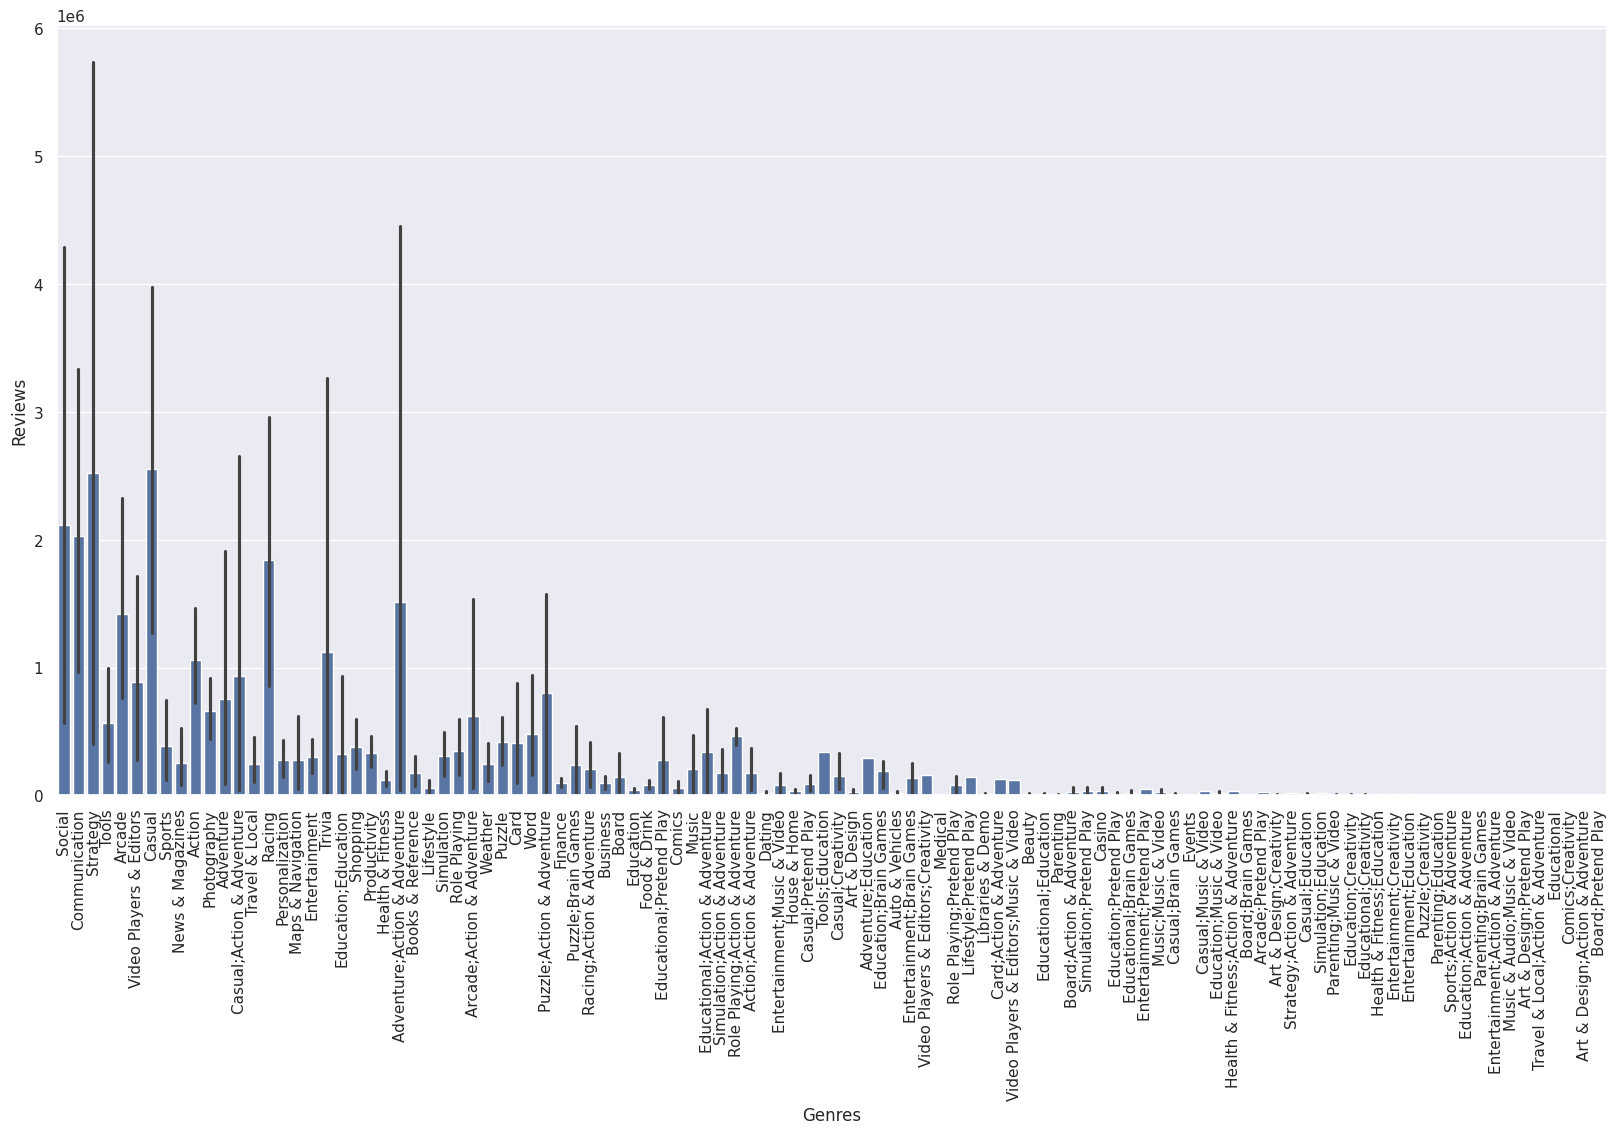

In [ ]:
sns.barplot(df,x='Genres',y='Reviews')
plt.xticks(rotation=90)
plt.show()

Casual, Strategy, Social, Communication, Racing, Adventure;Action & Adventure, Arcade

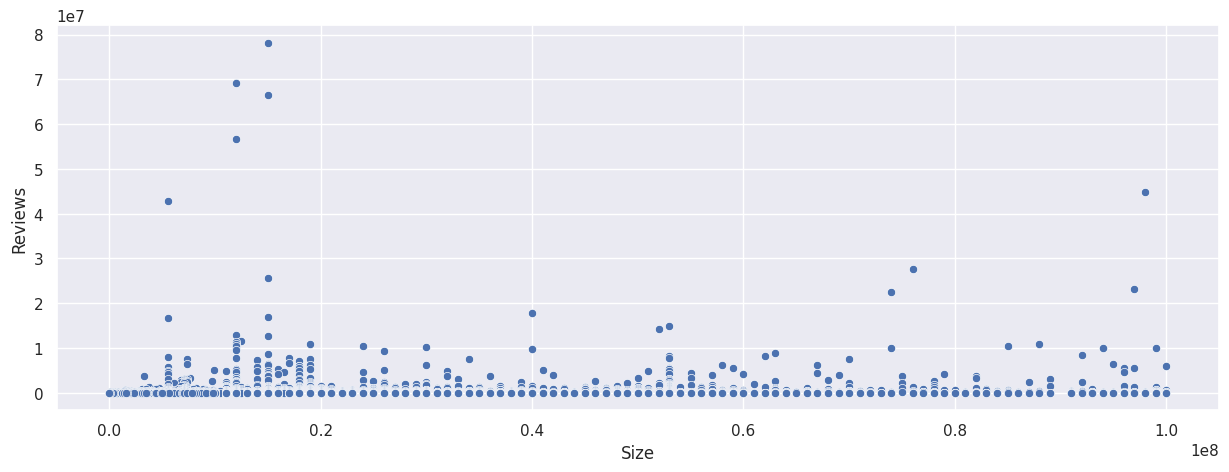

In [ ]:
sns.set(rc={'figure.figsize':(15,5)})
sns.scatterplot(df,x='Size',y='Reviews')
plt.show()

Lower size have higher density of reviews

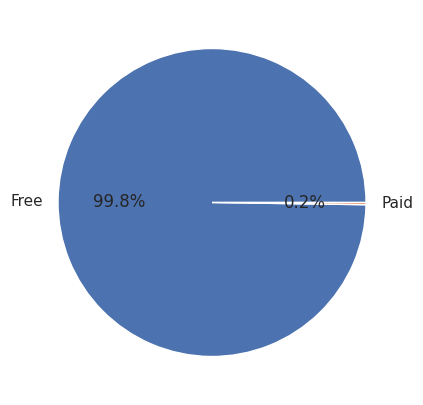

Total number of reviews for free apps: 1766096855
Total number of reviews for paid apps: 4013599


In [ ]:
sns.set(rc={'figure.figsize':(5,5)})
reviews_free = df[df['Price (in dollars)'] == 0.0]['Reviews'].sum()
reviews_paid = df[df['Price (in dollars)'] != 0.0]['Reviews'].sum()
plt.pie([reviews_free,reviews_paid],labels=['Free','Paid'],autopct='%1.1f%%')
plt.show()
print("Total number of reviews for free apps:",reviews_free)
print("Total number of reviews for paid apps:",reviews_paid)

In [ ]:
reviews_content_18 = df[df['Content_Rating_18+'] == 1]['Reviews'].sum()
reviews_content_17 = df[df['Content_Rating_17+'] == 1]['Reviews'].sum()
reviews_content_10 = df[df['Content_Rating_10+'] == 1]['Reviews'].sum()
reviews_everyone = df[df['Content Rating_Everyone'] == 1]['Reviews'].sum()
reviews_teen = df[df['Content Rating_Teen'] == 1]['Reviews'].sum()

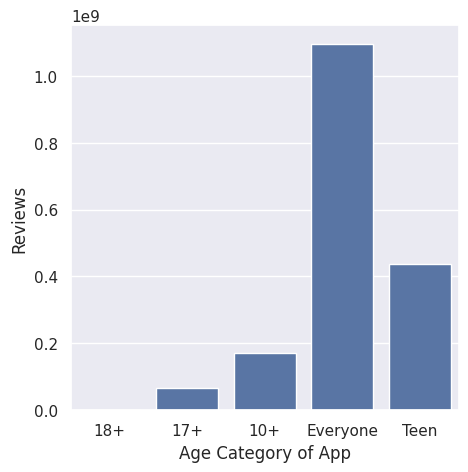

Total number of reviews for apps for 18+: 74022
Total number of reviews for apps for 17+: 67723628
Total number of reviews for apps for 10+: 169823638
Total number of reviews for apps for Everyone: 1095893187
Total number of reviews for apps for Teen: 436595979


In [ ]:
sns.barplot(x=['18+','17+','10+','Everyone','Teen'],y=[reviews_content_18,reviews_content_17,reviews_content_10,reviews_everyone,reviews_teen])
plt.xlabel('Age Category of App')
plt.ylabel('Reviews')
plt.show()
print("Total number of reviews for apps for 18+:",reviews_content_18)
print("Total number of reviews for apps for 17+:",reviews_content_17)
print("Total number of reviews for apps for 10+:",reviews_content_10)
print("Total number of reviews for apps for Everyone:",reviews_everyone)
print("Total number of reviews for apps for Teen:",reviews_teen)

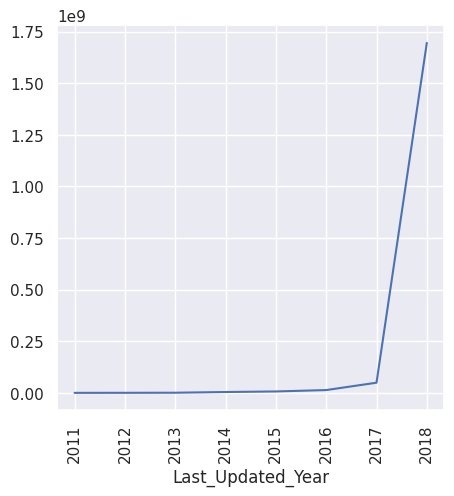


YEAR : REVIEWS
2011 : 8890
2012 : 228540
2013 : 667082
2014 : 4069956
2015 : 6817278
2016 : 13534990
2017 : 49234645
2018 : 1695549073


In [ ]:
reviews_last_updated_year = df.groupby('Last_Updated_Year')['Reviews'].sum()
sns.lineplot(x=reviews_last_updated_year.index,y=reviews_last_updated_year.values)
plt.xticks(rotation=90)
plt.show()
print()
print("YEAR : REVIEWS")
for i in range(len(reviews_last_updated_year.values)):
  print(reviews_last_updated_year.index[i],":",reviews_last_updated_year.values[i])